# SBI with cosmoGRID l1-norms

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Change "1" to the desired GPU index
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"  # Use 50% of GPU memory
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np

from jaxili.inference import NPE

# device = jax.devices("gpu")[0] 
print("Device used by jax:", jax.devices())

# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform" # Avoids preallocation of GPU memory

Device used by jax: [CudaDevice(id=0)]


In [2]:
params = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/cosmo_params.npy', allow_pickle=True)

# **BIN 1**

In [3]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms.npy', allow_pickle=True)

In [4]:
params.shape, l1_full.shape

((16965, 6), (16965, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16965, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scale1"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.


[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -11.217/ Best val loss -11.227:  17%|█▋        | 171/1000 [00:59<04:46,  2.89it/s]


Neural network training stopped after 172 epochs.
Early stopping with best validation metric: -11.227155685424805
Best model saved at epoch 151
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -11.448101997375488
[!] Validation loss: -11.227155685424805
[!] Test loss: -11.313217163085938


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [12]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin1.npy', allow_pickle=True)

In [13]:
np.array(fid_full).shape

(200, 5, 40)

In [14]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [15]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [16]:
import jax.random as random

master_key = random.PRNGKey(1)

In [17]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [18]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [19]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


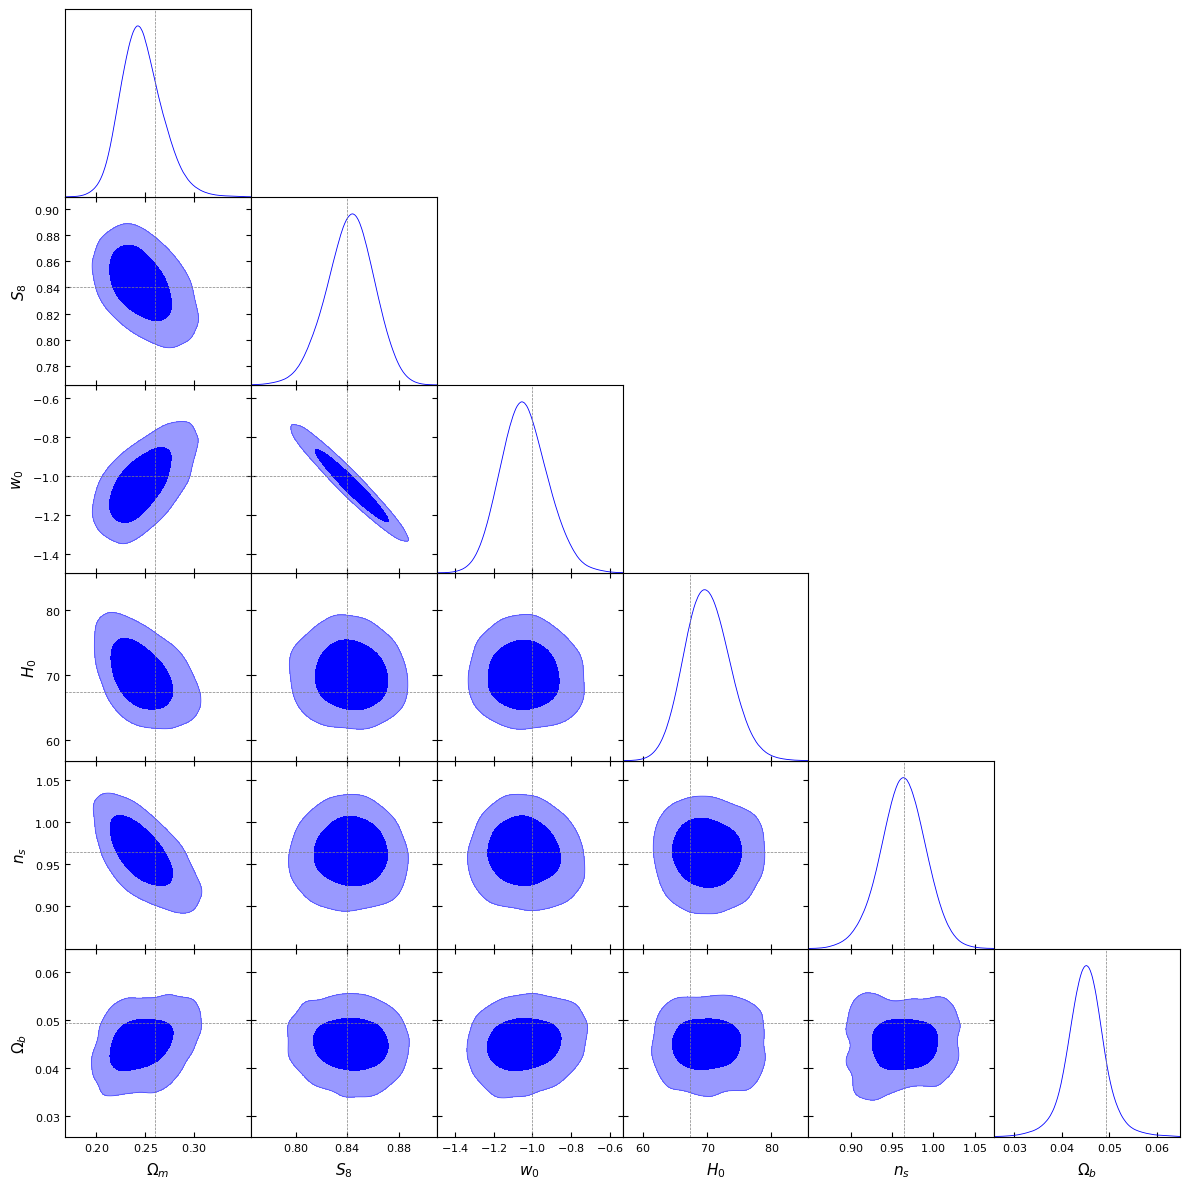

In [20]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [24]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin1_npe.npy", samples_gd_scale1.samples)

## Scale 2

In [27]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [28]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)
dataset = (params, l1_scale2)

In [29]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [30]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scale2"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -8.851/ Best val loss -8.862:  16%|█▌        | 160/1000 [00:57<05:01,  2.78it/s]

Neural network training stopped after 161 epochs.
Early stopping with best validation metric: -8.862065315246582
Best model saved at epoch 140
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -9.006684303283691
[!] Validation loss: -8.862065315246582
[!] Test loss: -8.9150390625


In [31]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [32]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid.npy', allow_pickle=True)

In [33]:
np.array(fid_full).shape

(200, 5, 40)

In [34]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [35]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [36]:
import jax.random as random

master_key = random.PRNGKey(1)

In [37]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [38]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [39]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


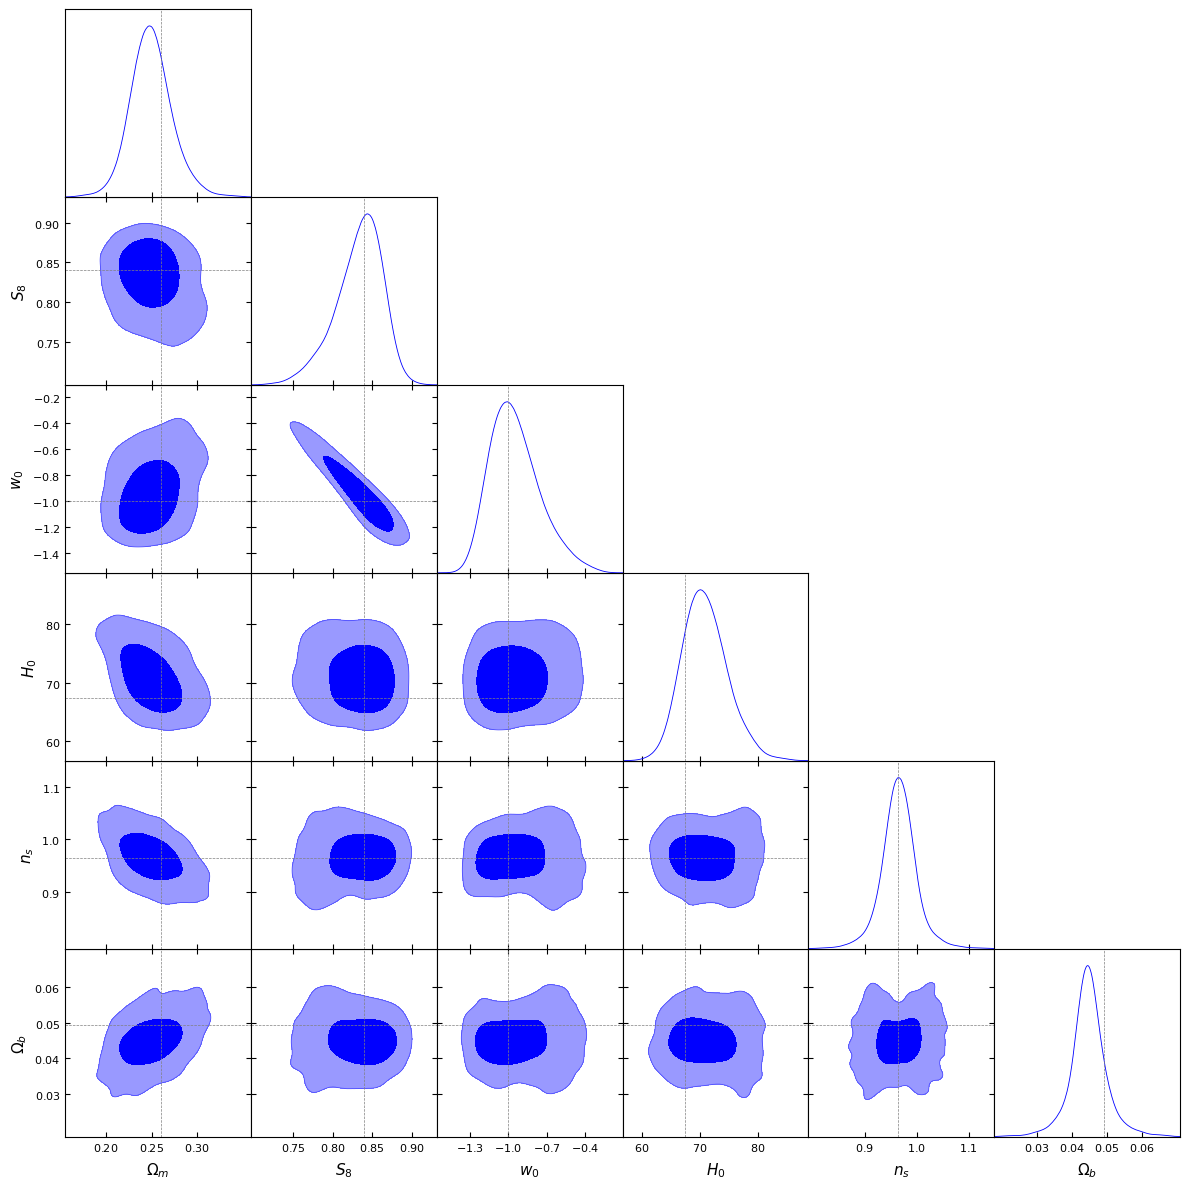

In [40]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 3

In [93]:
l1_scale3 = l1_full[:, 2]
l1_scale3.shape 

(16965, 40)

In [94]:
params = jnp.array(params)
l1_scale3 = jnp.array(l1_scale3)
dataset = (params, l1_scale3)

In [95]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [96]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scale3"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -7.470/ Best val loss -7.499:  18%|█▊        | 175/1000 [01:00<04:47,  2.87it/s]

Neural network training stopped after 176 epochs.
Early stopping with best validation metric: -7.499131679534912
Best model saved at epoch 155
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.625226974487305
[!] Validation loss: -7.499131679534912
[!] Test loss: -7.4355621337890625


In [97]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [98]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid.npy', allow_pickle=True)

In [99]:
np.array(fid_full).shape

(200, 5, 40)

In [100]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [101]:
fid_mean_scale3 = fid_mean[2]
fid_mean_scale3.shape

(40,)

Sampling

In [102]:
import jax.random as random

master_key = random.PRNGKey(1)

In [103]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale3, num_samples=num_samples, key=sample_key
)

In [104]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [105]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


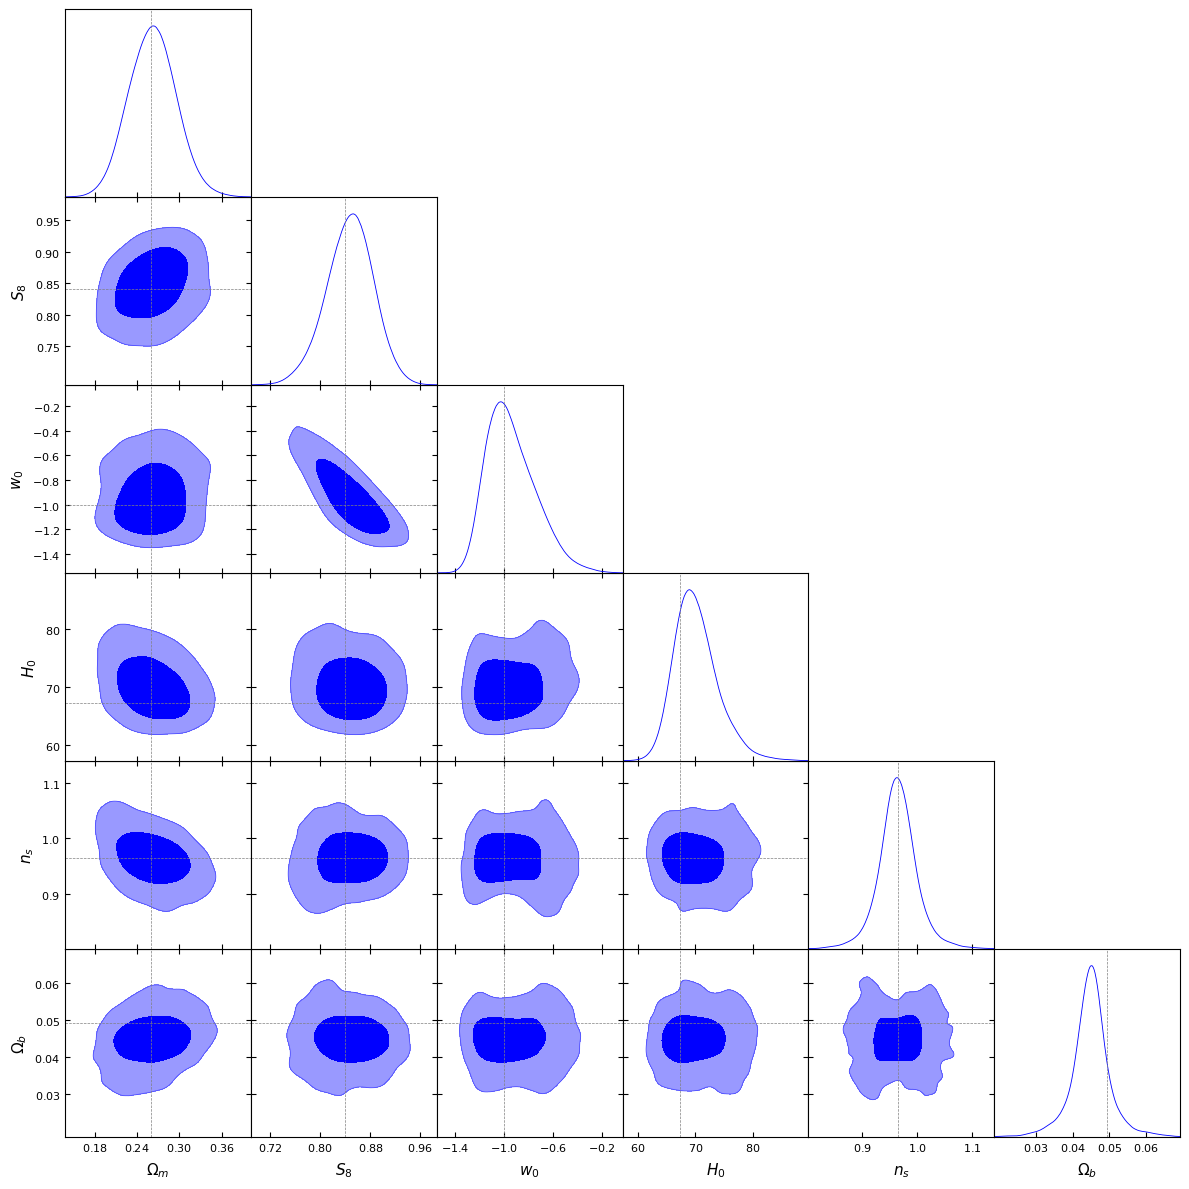

In [106]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

Removed no burn in


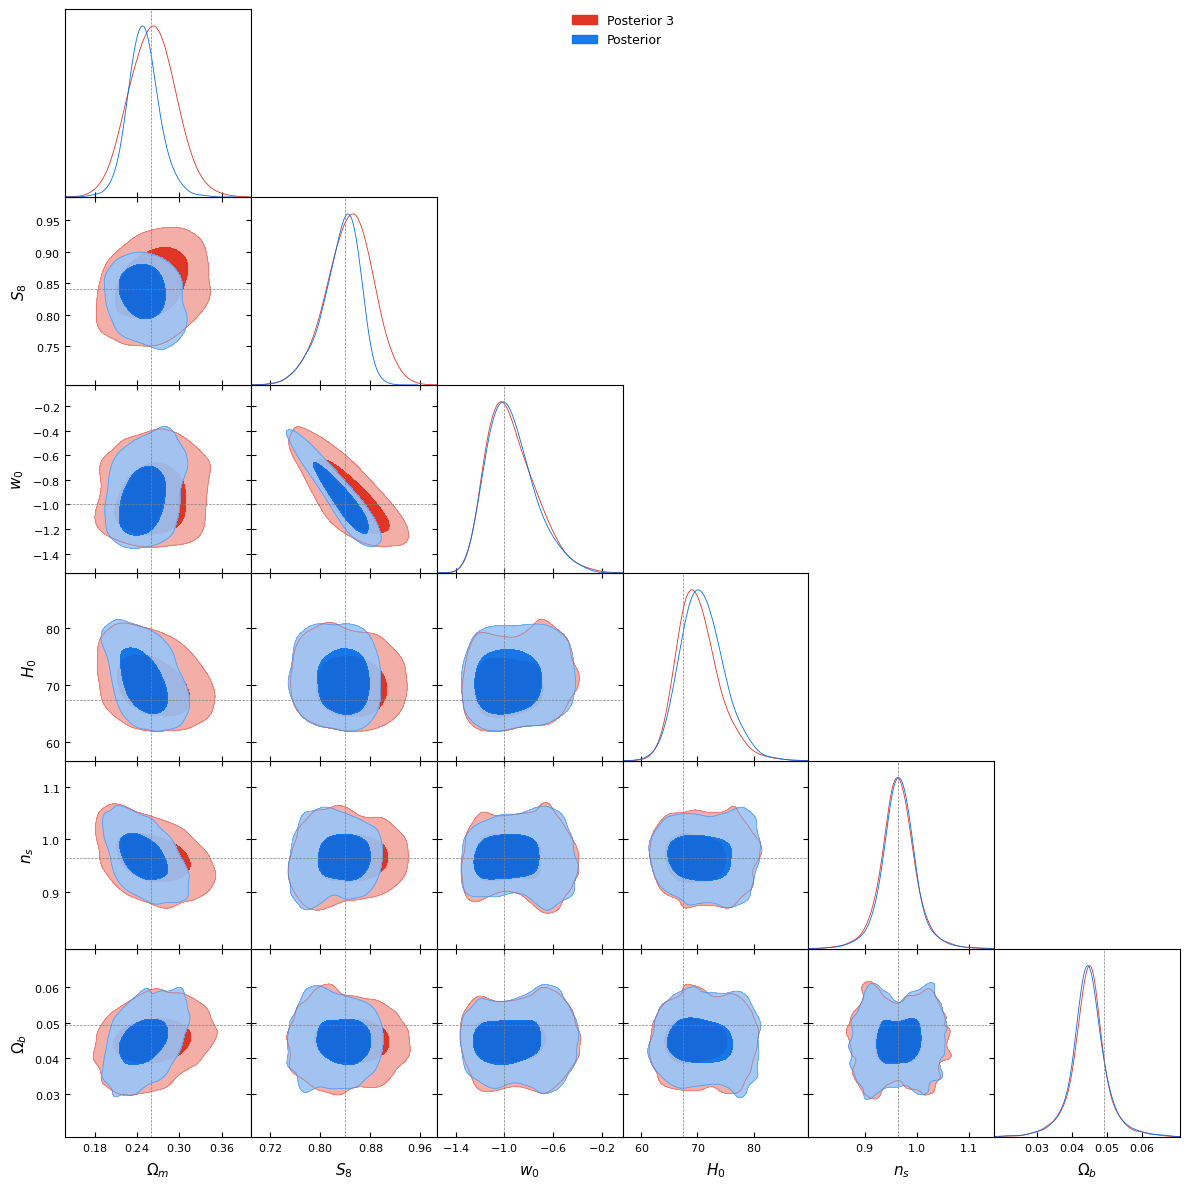

In [107]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.9

g.triangle_plot([samples_gd_scale3, samples_gd], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 4

In [62]:
l1_scale4 = l1_full[:, 3]
l1_scale4.shape 

(16965, 40)

In [63]:
params = jnp.array(params)
l1_scale4 = jnp.array(l1_scale4)
dataset = (params, l1_scale4)

In [64]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [65]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scale4"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.


Could not tabulate model: 
[!] Training the density estimator.


Epochs: Val loss -6.313/ Best val loss -6.334:  14%|█▍        | 144/1000 [00:55<05:32,  2.57it/s]

Neural network training stopped after 145 epochs.
Early stopping with best validation metric: -6.333599090576172
Best model saved at epoch 124
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.499903202056885
[!] Validation loss: -6.333599090576172
[!] Test loss: -6.346879005432129


In [66]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [67]:
fid_mean_scale4 = fid_mean[3]
fid_mean_scale4.shape

(40,)

Sampling

In [68]:
import jax.random as random

master_key = random.PRNGKey(1)

In [69]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale4, num_samples=num_samples, key=sample_key
)

In [70]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [71]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


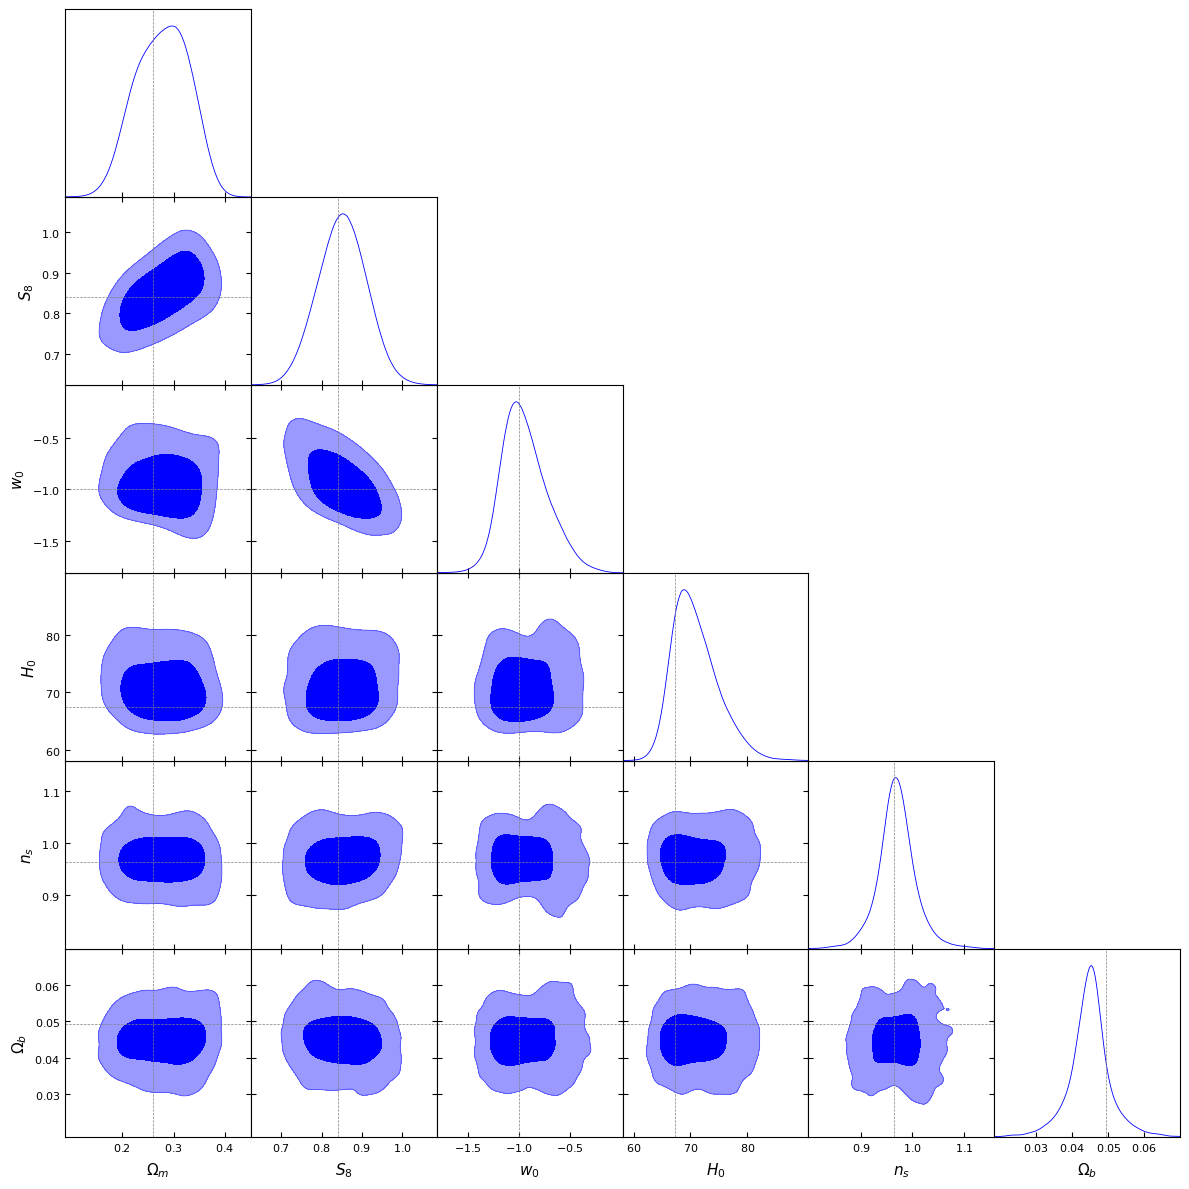

In [74]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale4 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

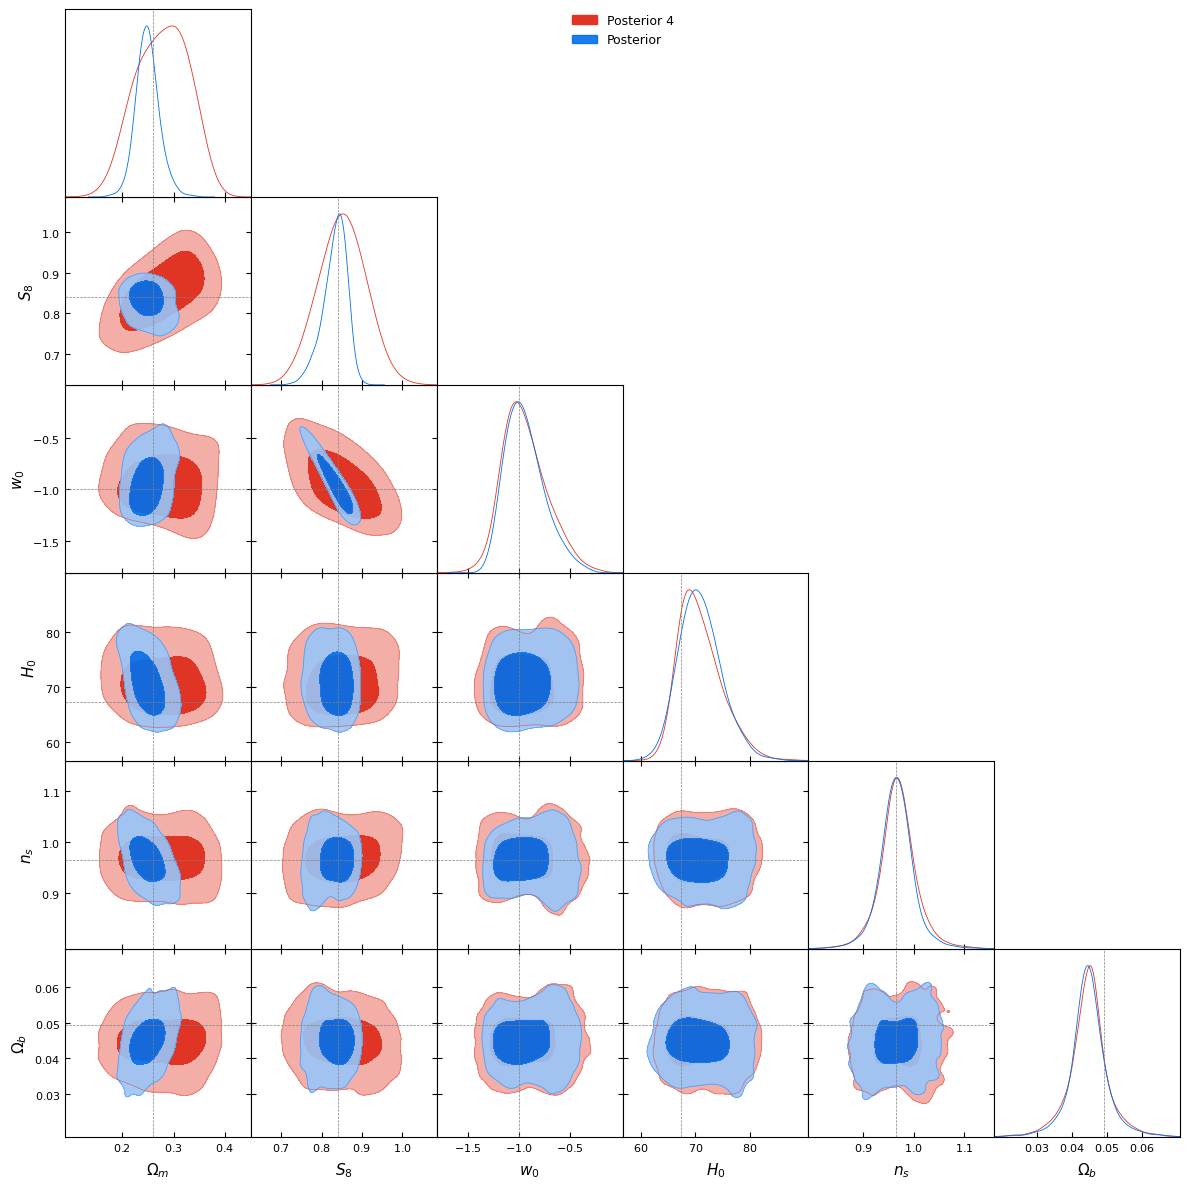

In [75]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.9

g.triangle_plot([samples_gd_scale4, samples_gd], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## Scale 5

In [77]:
l1_scale5 = l1_full[:, 4]
l1_scale5.shape 

(16965, 40)

In [78]:
params = jnp.array(params)
l1_scale5 = jnp.array(l1_scale5)
dataset = (params, l1_scale5)

In [79]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [80]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scale5"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -5.340/ Best val loss -5.367:  10%|▉         | 95/1000 [00:35<05:39,  2.67it/s]

Neural network training stopped after 96 epochs.
Early stopping with best validation metric: -5.366785526275635
Best model saved at epoch 75
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.520446300506592
[!] Validation loss: -5.366785526275635
[!] Test loss: -5.374850749969482


In [81]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [82]:
fid_mean_scale5 = fid_mean[4]
fid_mean_scale5.shape

(40,)

Sampling

In [83]:
import jax.random as random

master_key = random.PRNGKey(1)

In [84]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale5, num_samples=num_samples, key=sample_key
)

In [85]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [86]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


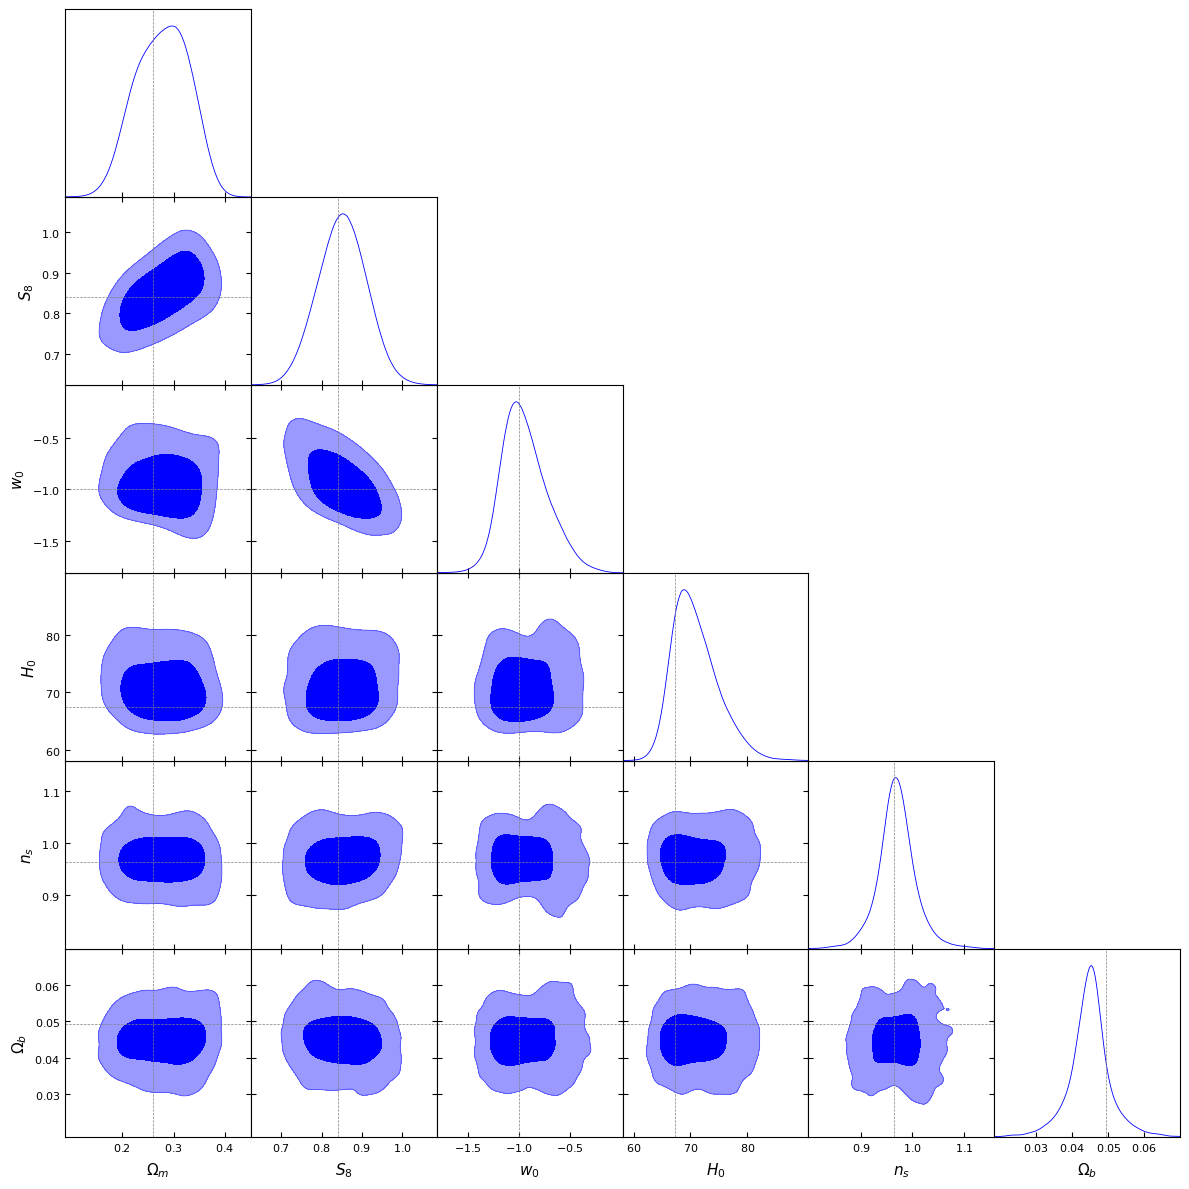

In [87]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale5 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

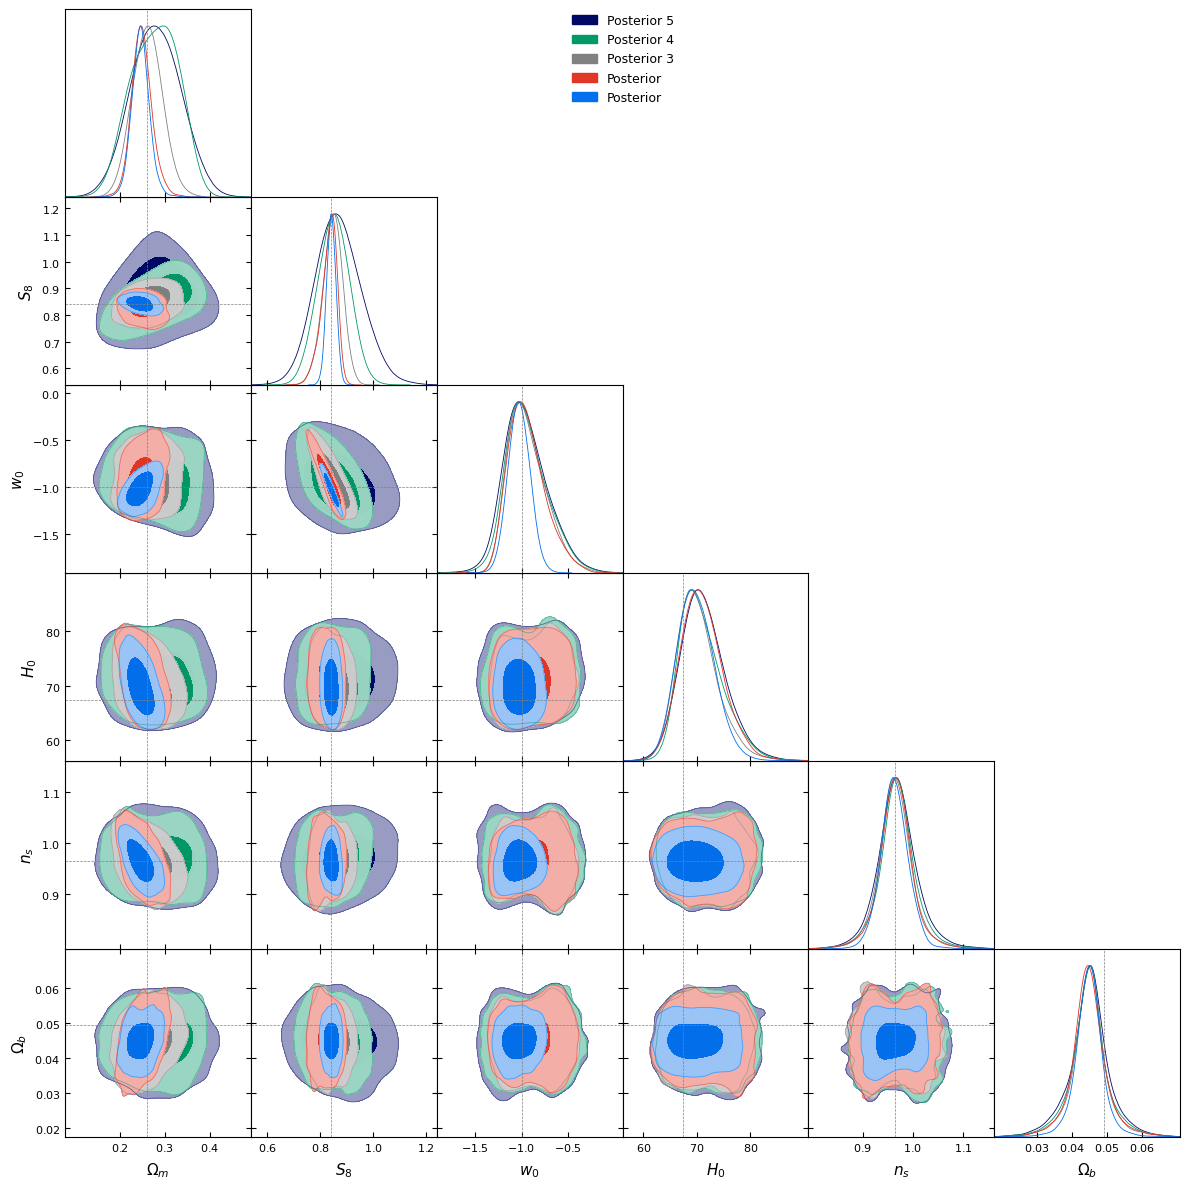

In [128]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_gd_scale5, samples_gd_scale4, samples_gd_scale3, samples_gd, samples_gd_scale1], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

In [ ]:
# save the MCSamples
import numpy as np

# save the MCSamples


In [129]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin1_npe.npy", samples_gd_scale1.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin1_npe.npy", samples_gd.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin1_npe.npy", samples_gd_scale3.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin1_npe.npy", samples_gd_scale4.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin1_npe.npy", samples_gd_scale5.samples)

In [143]:
samples1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin1_npe.npy")
samples2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin1_npe.npy")
samples3 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin1_npe.npy")
samples4 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin1_npe.npy")
samples5 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin1_npe.npy")
samples = [samples1, samples2, samples3, samples4, samples5]

In [137]:
samples_scale5 = MCSamples(
    samples=samples5,
    names=labels,
    label="Posterior 5",
)

Removed no burn in


In [146]:
samples_scale = []
for i in range(5):
    samples_scale_i = MCSamples(samples=samples[i], names=labels, label=f"Posterior {i+1}")
    samples_scale.append(samples_scale_i)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


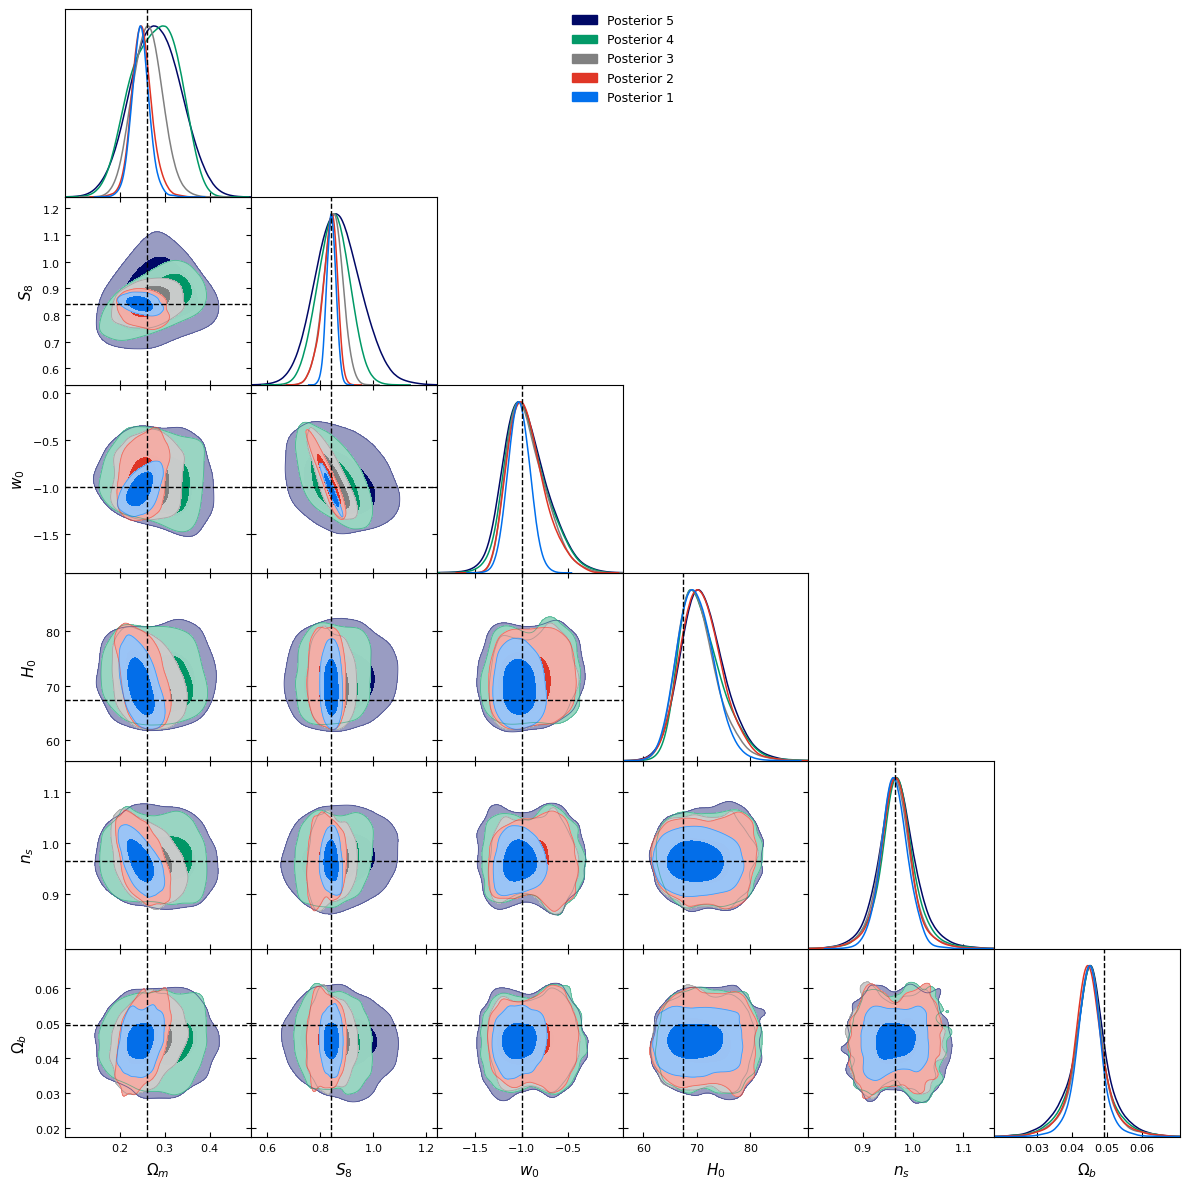

In [161]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[4], samples_scale[3], samples_scale[2], samples_scale[1], samples_scale[0]], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_each_scale_bin1_npe.pdf")
plt.show()

# Combine Scales

## 1+2

In [170]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
# combine the two scale histograms
l1_scales_1_2 = np.concatenate((l1_scale1, l1_scale2), axis=1)
l1_scales_1_2.shape 

(16965, 80)

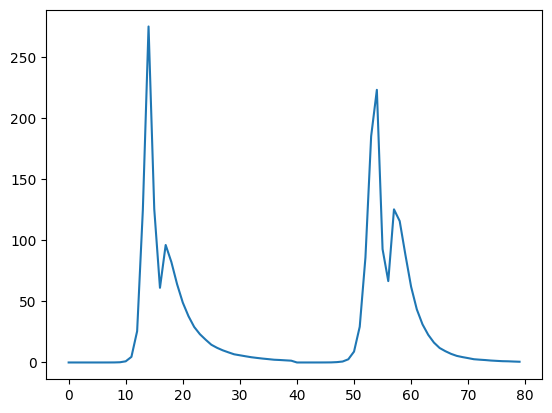

In [177]:
plt.plot(l1_scales_1_2[5])

In [178]:
params = jnp.array(params)
l1_scales_1_2 = jnp.array(l1_scales_1_2)
dataset = (params, l1_scales_1_2)

In [179]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [181]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1_2"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -11.632/ Best val loss -11.736:  20%|██        | 204/1000 [01:09<04:32,  2.92it/s]

Neural network training stopped after 205 epochs.
Early stopping with best validation metric: -11.735834121704102
Best model saved at epoch 184
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -11.953622817993164
[!] Validation loss: -11.735834121704102
[!] Test loss: -11.50783920288086


In [182]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [184]:
fid_mean_scales_1_2 = np.concatenate((fid_mean[0], fid_mean[1]))
fid_mean_scales_1_2.shape

(80,)

Sampling

In [186]:
import jax.random as random

master_key = random.PRNGKey(1)

In [187]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2, num_samples=num_samples, key=sample_key
)

In [188]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [189]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


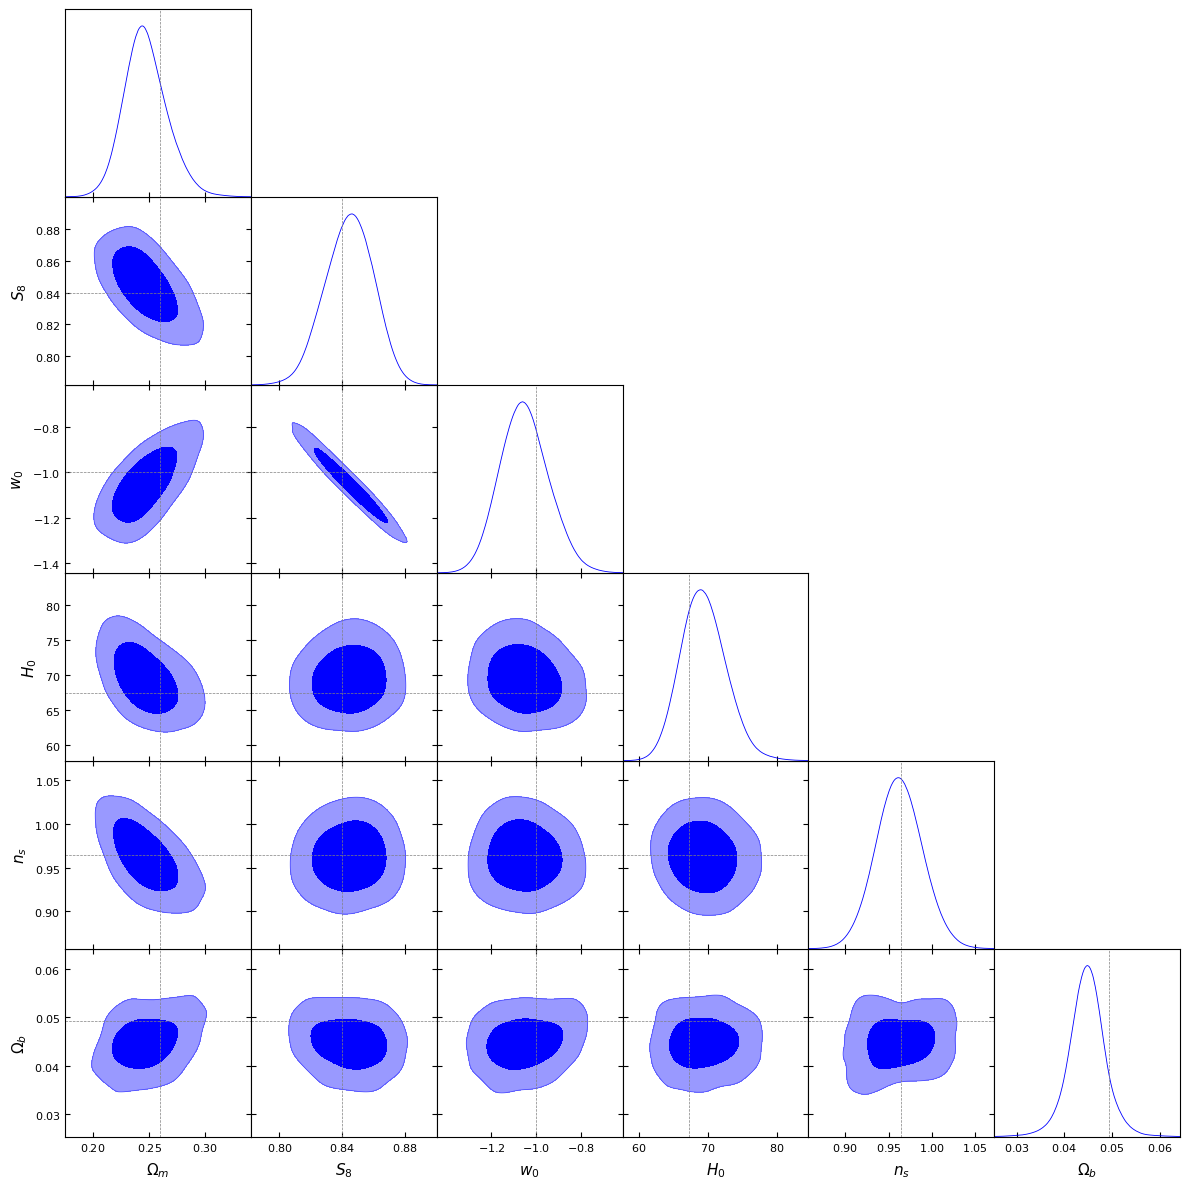

In [191]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [194]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1_2_bin1_npe.npy", samples_gd_scales_1_2.samples)

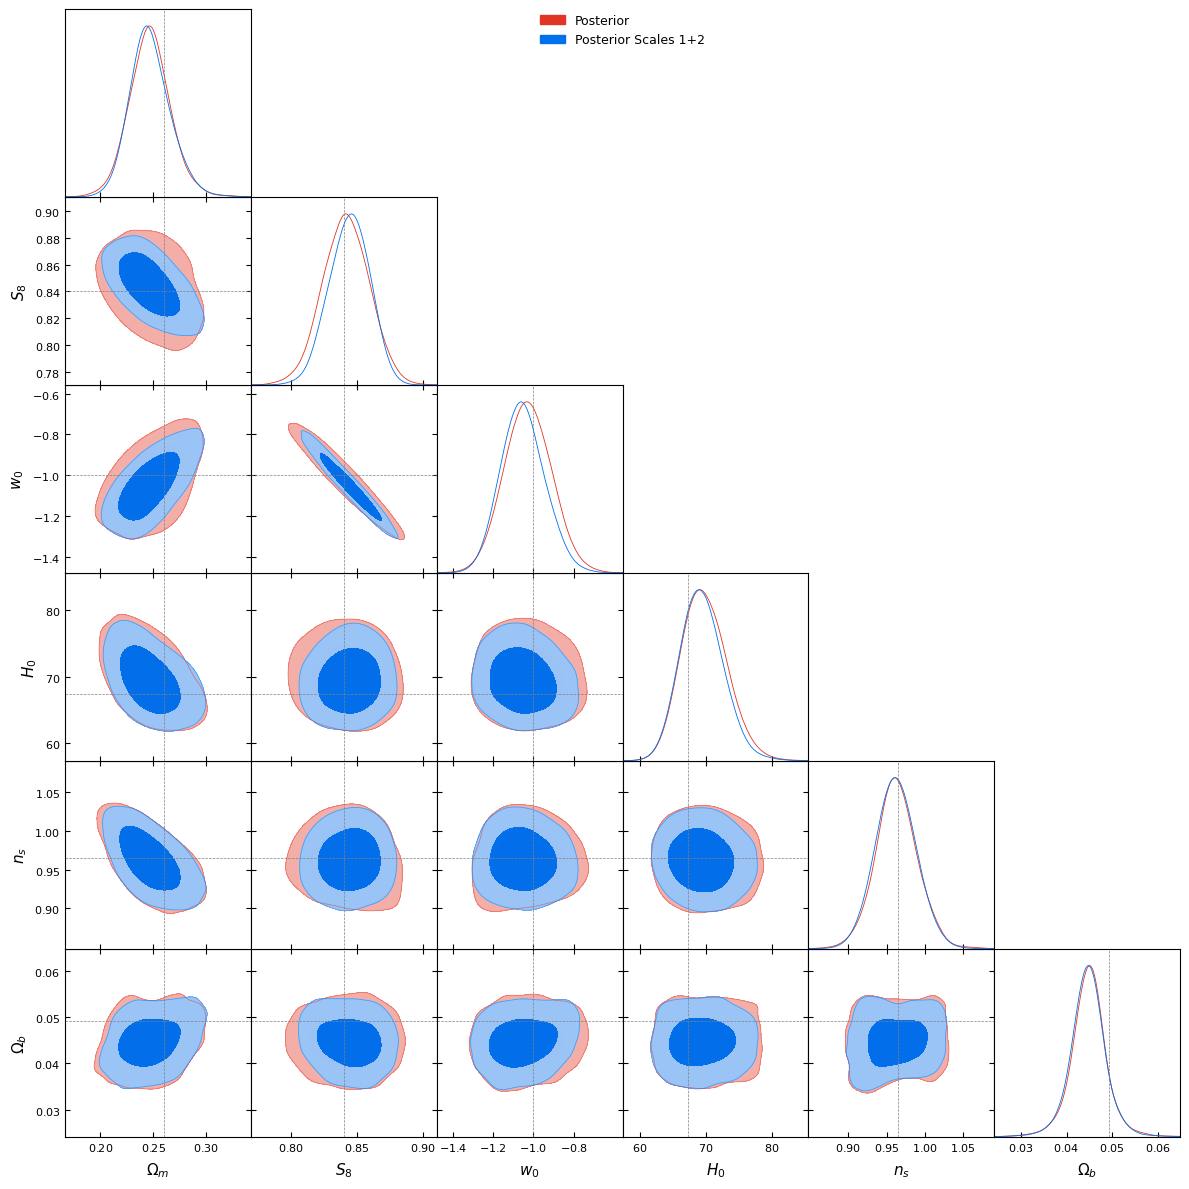

In [195]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_gd_scale1, samples_gd_scales_1_2], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## 1+2+3

In [196]:
l1_scale1 = l1_full[:, 0]
l1_scale2 = l1_full[:, 1]
l1_scale3 = l1_full[:, 2]
# combine the two scale histograms
l1_scales_1_2_3 = np.concatenate((l1_scale1, l1_scale2, l1_scale3), axis=1)
l1_scales_1_2_3.shape 

(16965, 120)

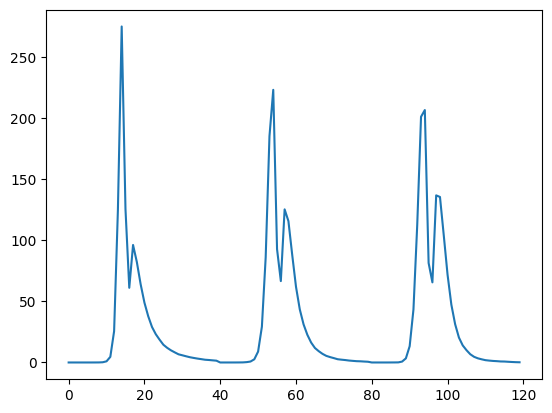

In [197]:
plt.plot(l1_scales_1_2_3[5])

In [198]:
params = jnp.array(params)
l1_scales_1_2_3 = jnp.array(l1_scales_1_2_3)
dataset = (params, l1_scales_1_2_3)

In [199]:
inference = NPE()
inference = inference.append_simulations(params, l1_scales_1_2_3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [200]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_scales_1_2_3"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -11.586/ Best val loss -11.641:  20%|██        | 203/1000 [01:09<04:33,  2.91it/s]

Neural network training stopped after 204 epochs.
Early stopping with best validation metric: -11.64136791229248
Best model saved at epoch 183
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -12.020724296569824
[!] Validation loss: -11.64136791229248
[!] Test loss: -11.658646583557129


In [201]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [202]:
fid_mean_scales_1_2_3 = np.concatenate((fid_mean[0], fid_mean[1], fid_mean[2]))
fid_mean_scales_1_2_3.shape

(120,)

Sampling

In [204]:
import jax.random as random

master_key = random.PRNGKey(1)

In [205]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scales_1_2_3, num_samples=num_samples, key=sample_key
)

In [206]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [207]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


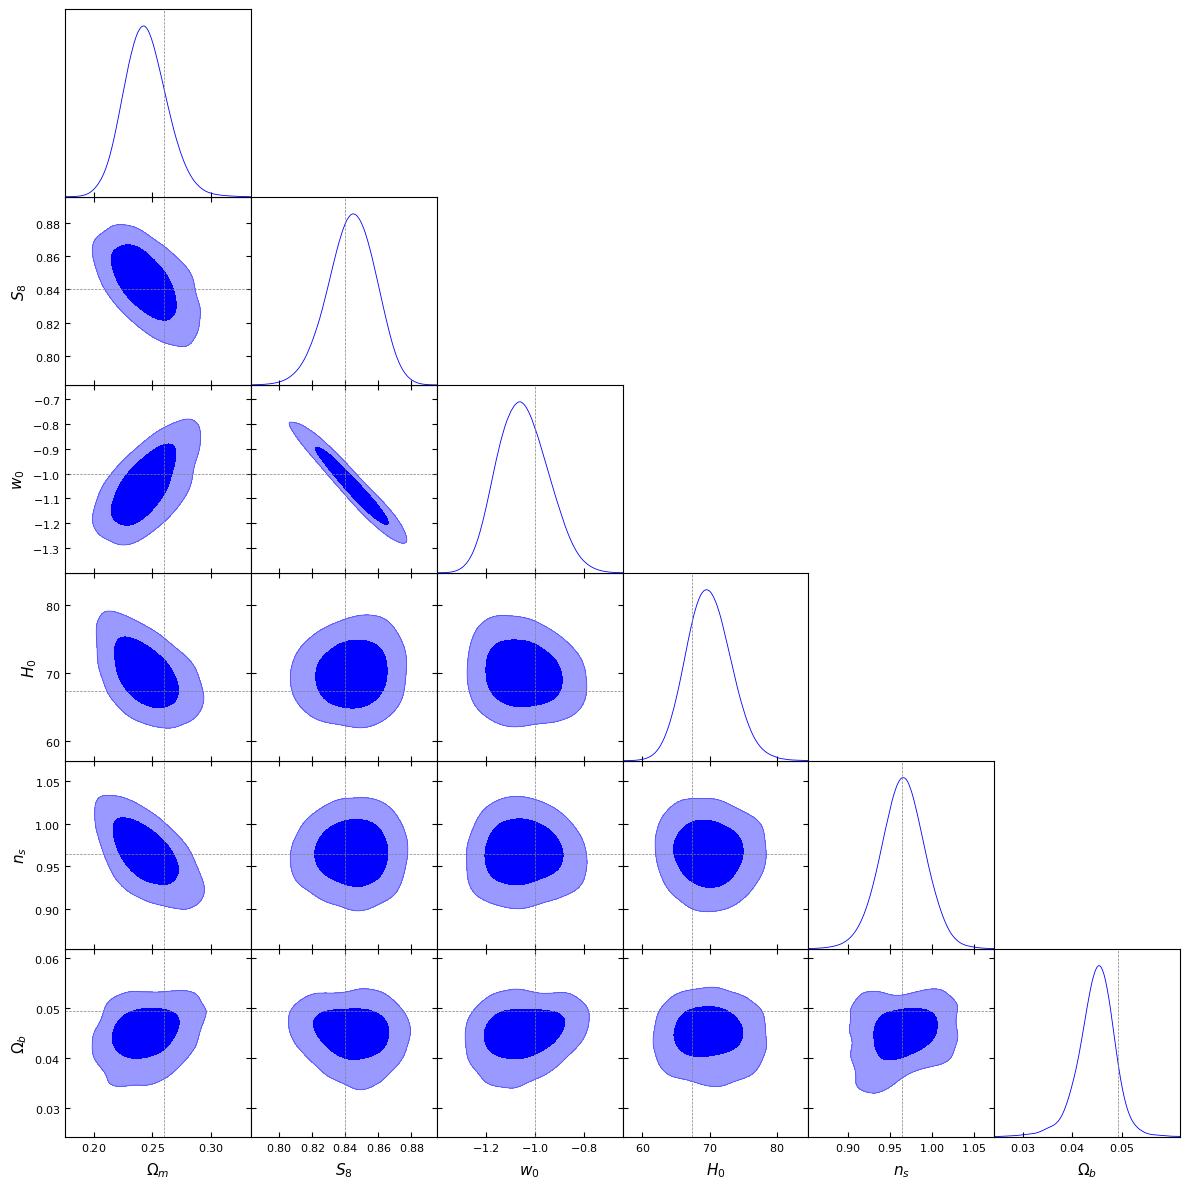

In [208]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scales_1_2_3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior Scales 1+2+3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scales_1_2_3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [209]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scales_1_2_3_bin1_npe.npy", samples_gd_scales_1_2_3.samples)

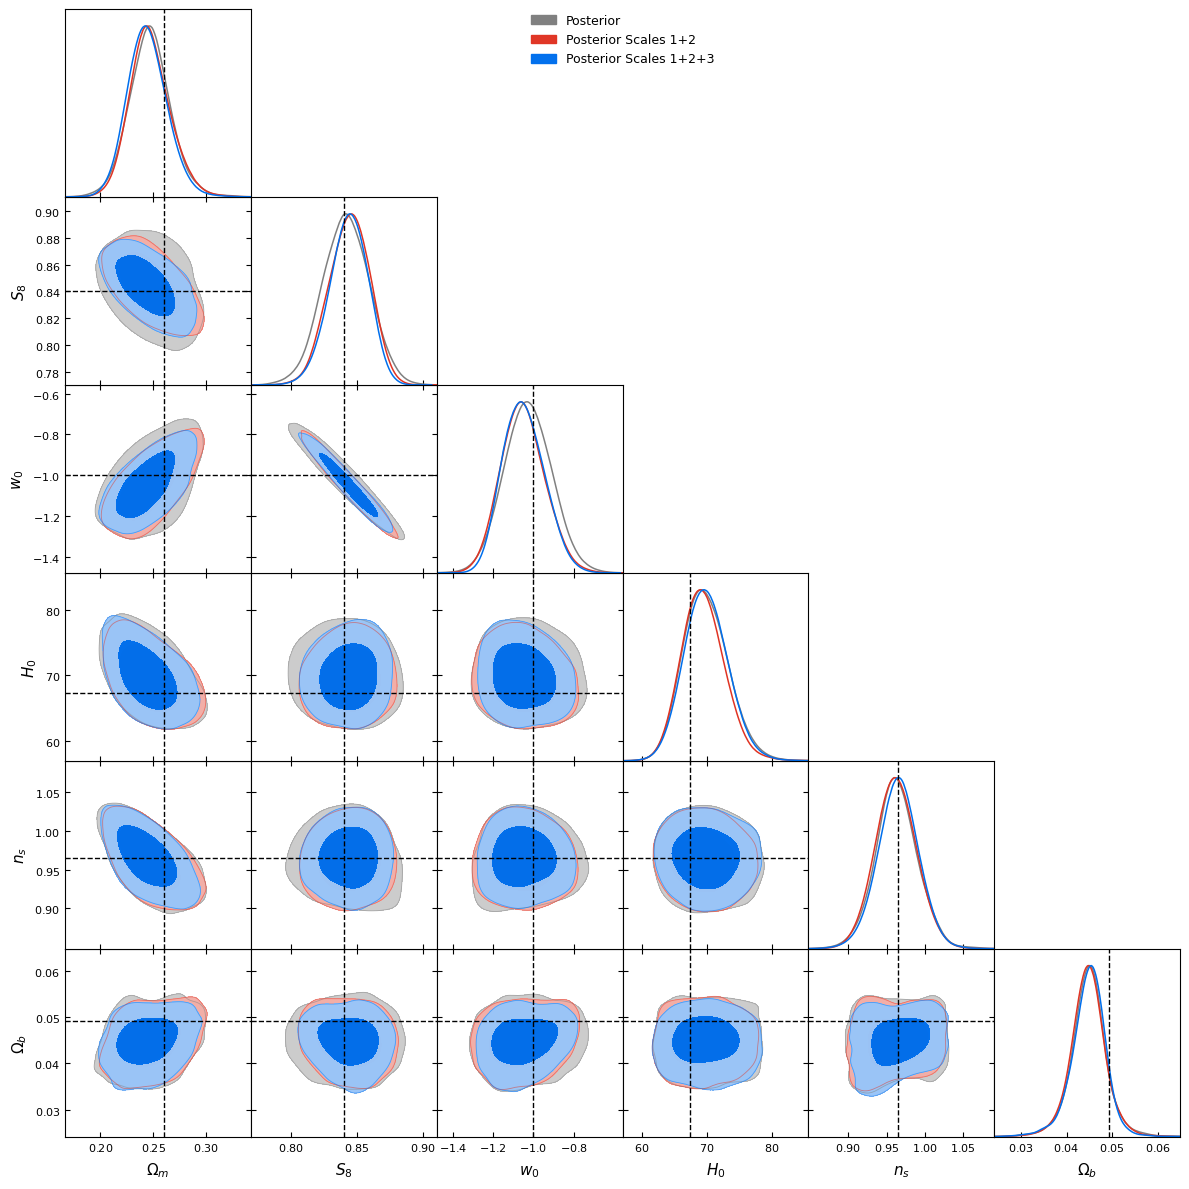

In [211]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_gd_scale1, samples_gd_scales_1_2, samples_gd_scales_1_2_3], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_combined_scales_bin1_npe.pdf")
plt.show()

# **BIN 2**

In [3]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin2.npy', allow_pickle=True)

In [4]:
params.shape, l1_full.shape

((16965, 6), (16965, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16965, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.


[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin2_scale1"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -11.344/ Best val loss -11.415:  21%|██        | 212/1000 [01:13<04:32,  2.89it/s]

Neural network training stopped after 213 epochs.
Early stopping with best validation metric: -11.414546966552734
Best model saved at epoch 192
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -11.642127990722656
[!] Validation loss: -11.414546966552734
[!] Test loss: -11.272207260131836


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [12]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin2.npy', allow_pickle=True)

In [13]:
np.array(fid_full).shape

(200, 5, 40)

In [14]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [15]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [16]:
import jax.random as random

master_key = random.PRNGKey(1)

In [17]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [18]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [19]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


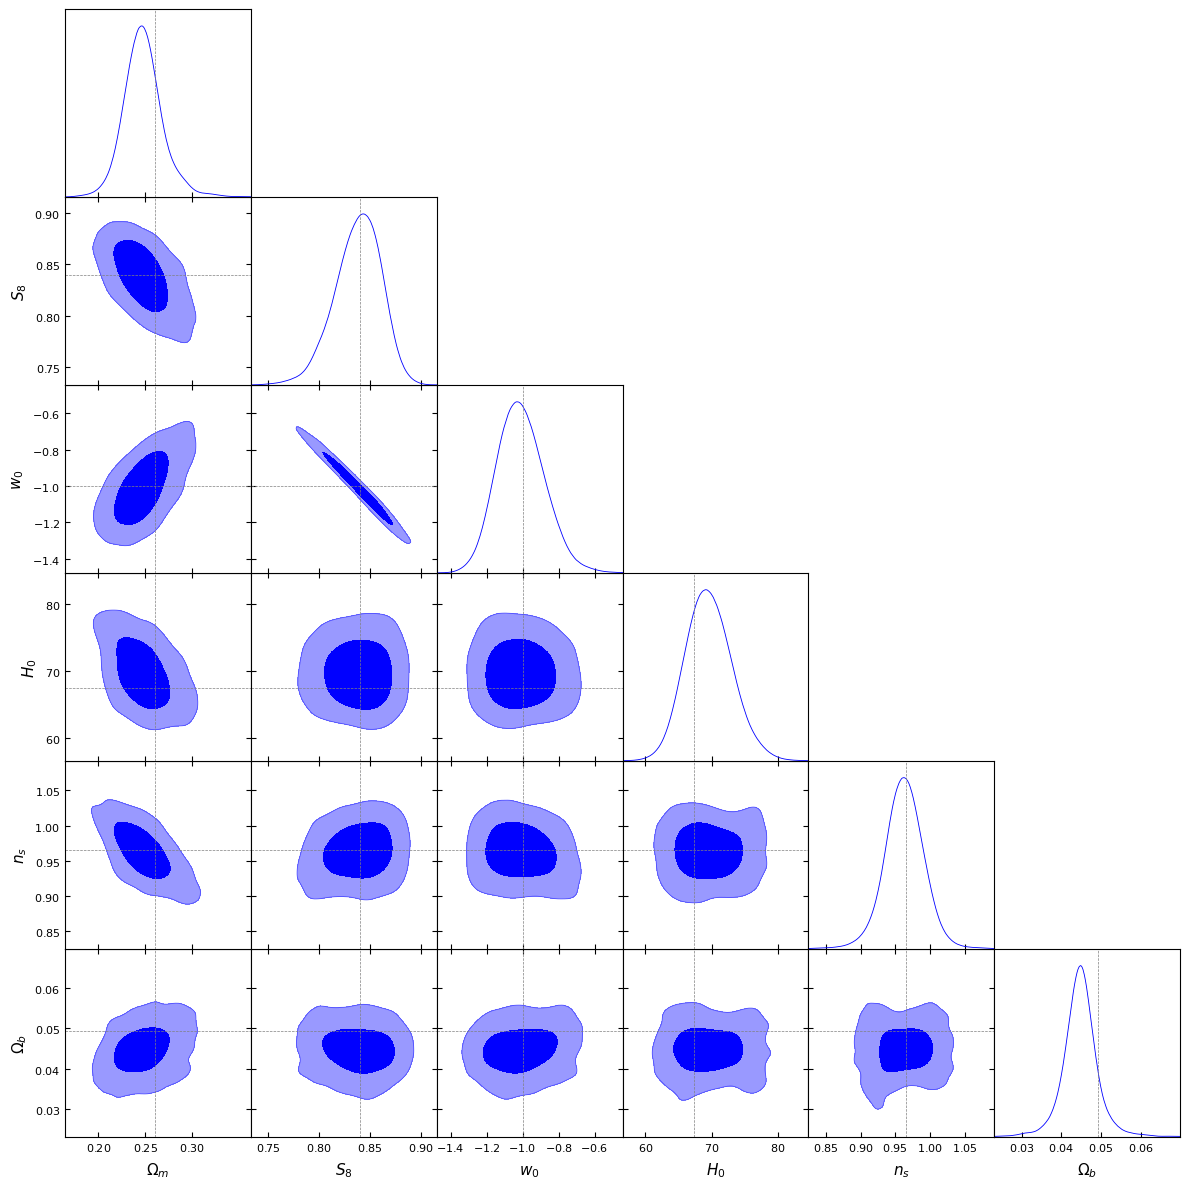

In [20]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 2

In [21]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [22]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)
dataset = (params, l1_scale2)

In [23]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [24]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin2_scale2"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -8.801/ Best val loss -8.840:  20%|█▉        | 196/1000 [01:06<04:31,  2.96it/s]

Neural network training stopped after 197 epochs.
Early stopping with best validation metric: -8.839653015136719
Best model saved at epoch 176
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.862283706665039
[!] Validation loss: -8.839653015136719
[!] Test loss: -8.751097679138184


In [25]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [26]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin2.npy', allow_pickle=True)

In [27]:
np.array(fid_full).shape

(200, 5, 40)

In [28]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [29]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [30]:
import jax.random as random

master_key = random.PRNGKey(1)

In [31]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [32]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [33]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


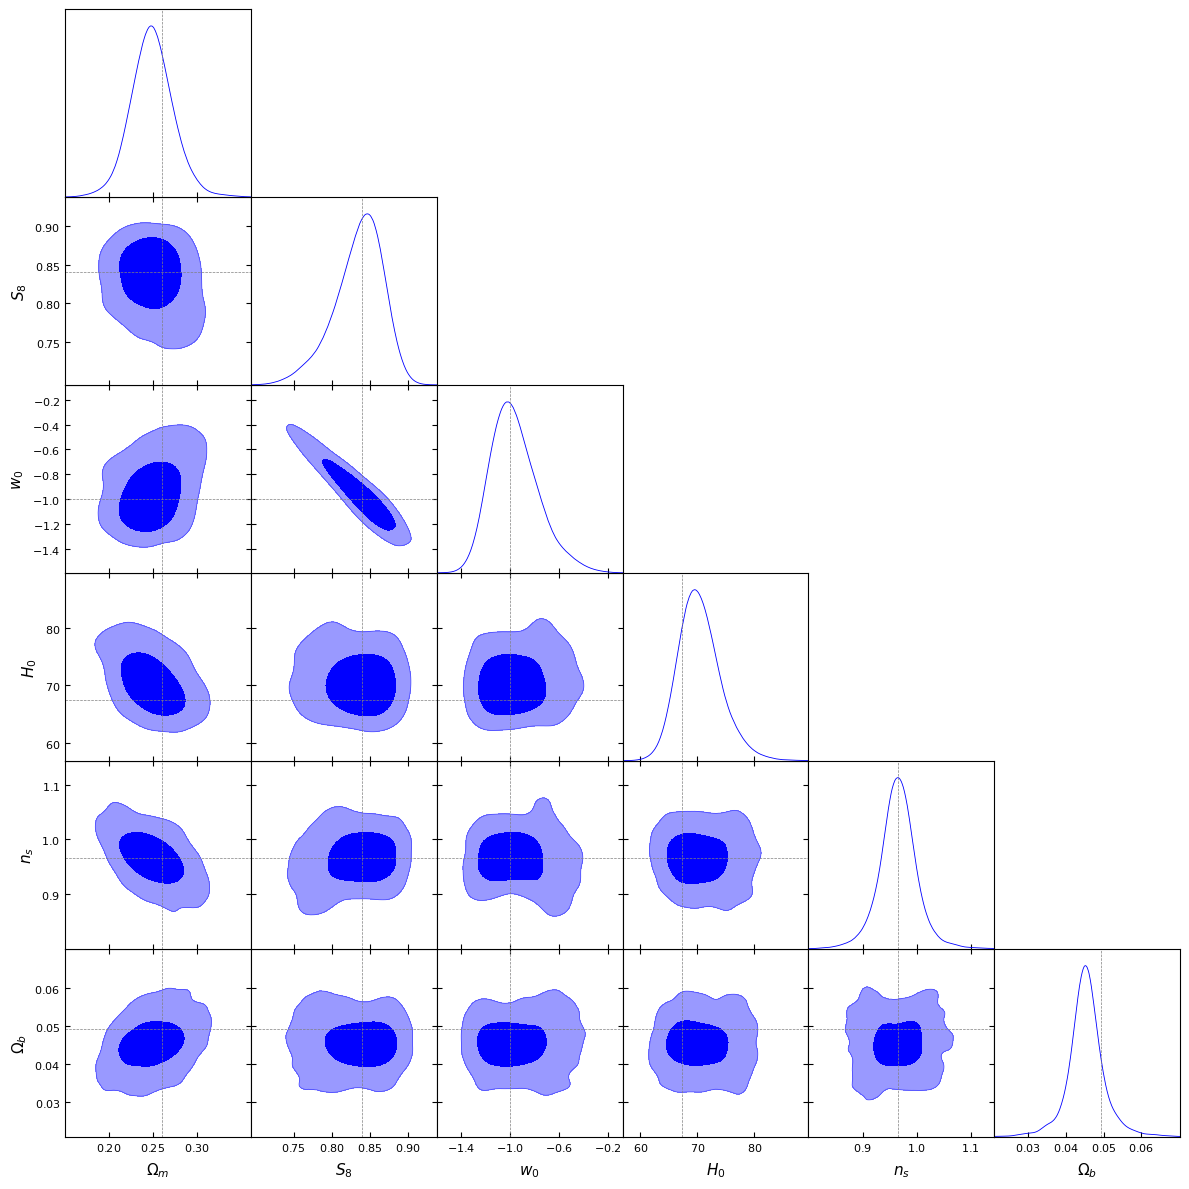

In [34]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 3

In [35]:
l1_scale3 = l1_full[:, 2]
l1_scale3.shape 

(16965, 40)

In [36]:
params = jnp.array(params)
l1_scale3 = jnp.array(l1_scale3)
dataset = (params, l1_scale3)

In [37]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [38]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin2_scale3"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.


Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -7.288/ Best val loss -7.299:  20%|██        | 203/1000 [01:09<04:32,  2.92it/s]

Neural network training stopped after 204 epochs.
Early stopping with best validation metric: -7.299273490905762
Best model saved at epoch 183
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -7.426222324371338
[!] Validation loss: -7.299273490905762
[!] Test loss: -7.243268966674805


In [39]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [40]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin2.npy', allow_pickle=True)

In [41]:
np.array(fid_full).shape

(200, 5, 40)

In [42]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [43]:
fid_mean_scale3 = fid_mean[2]
fid_mean_scale3.shape

(40,)

Sampling

In [44]:
import jax.random as random

master_key = random.PRNGKey(1)

In [45]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale3, num_samples=num_samples, key=sample_key
)

In [46]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [47]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


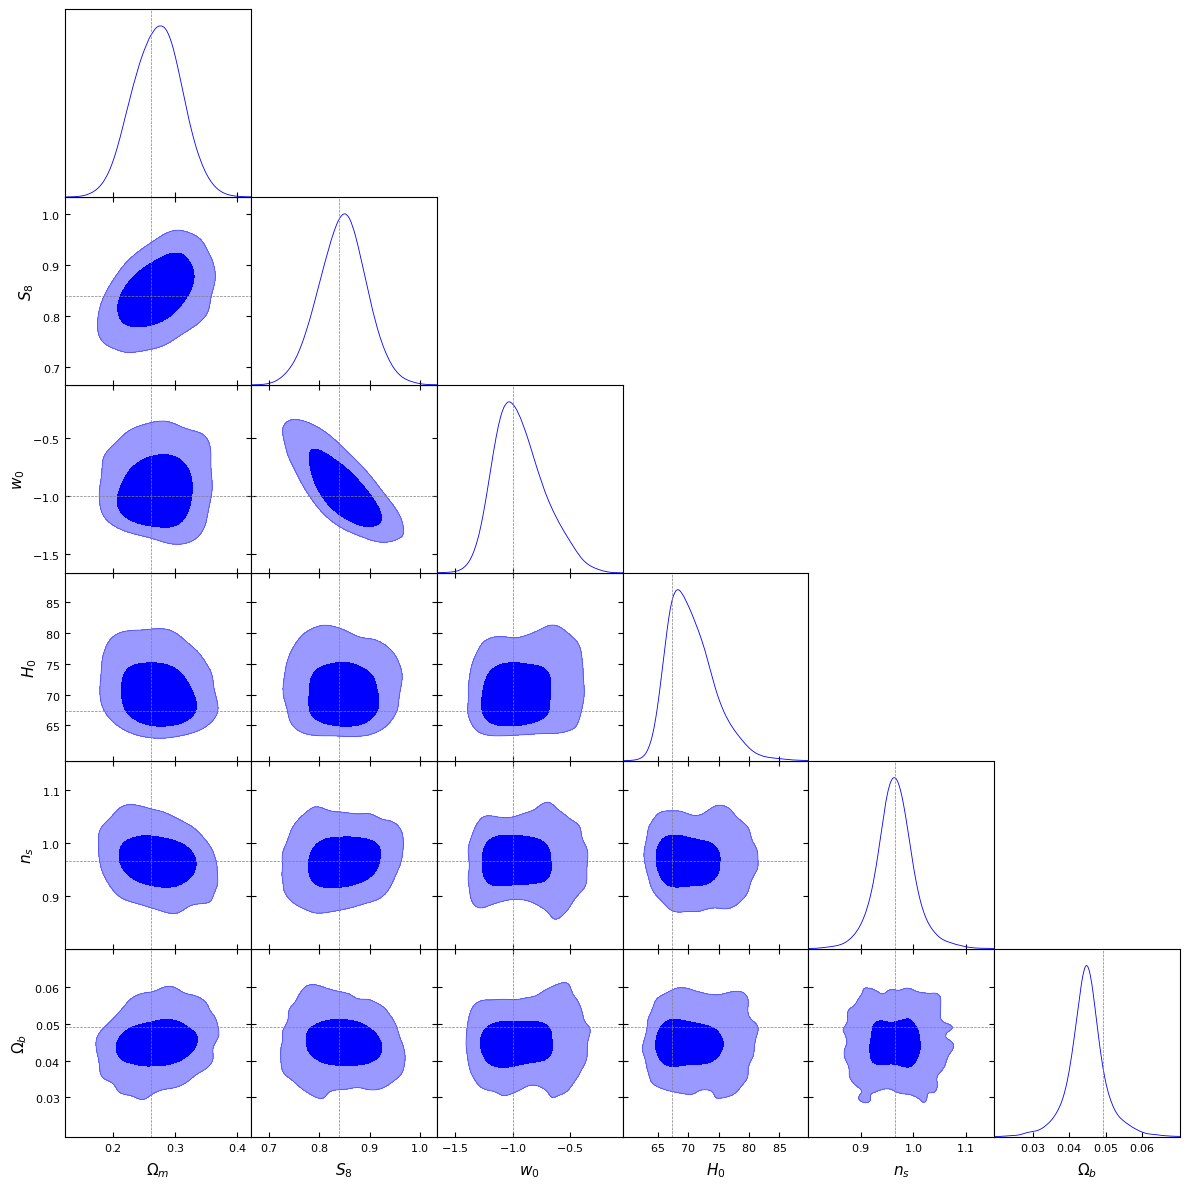

In [48]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

Removed no burn in


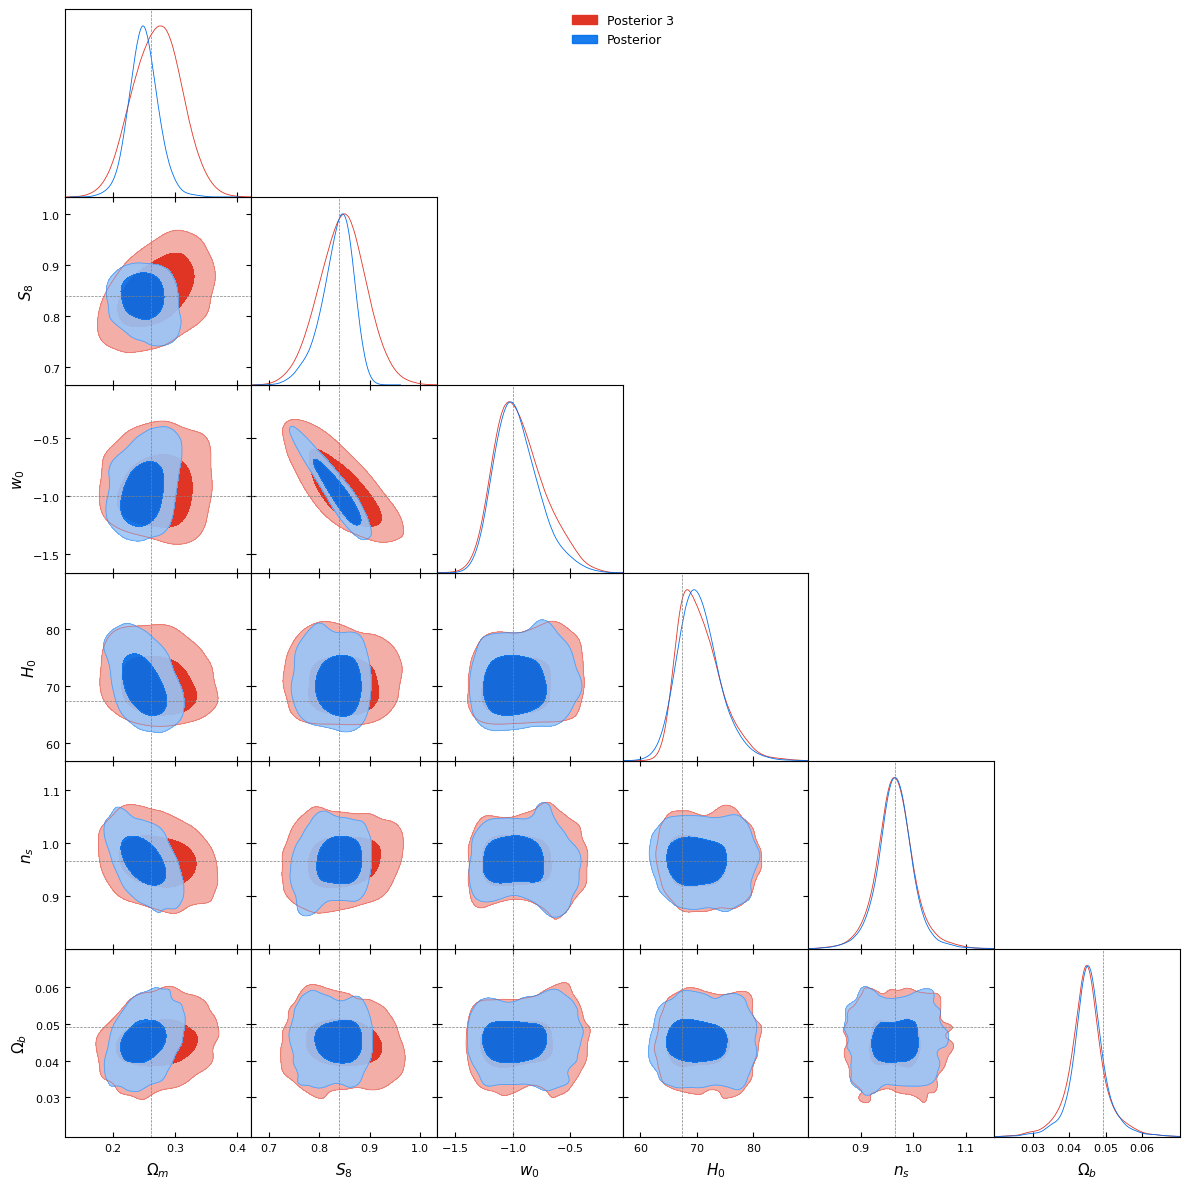

In [49]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.9

g.triangle_plot([samples_gd_scale3, samples_gd], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 4

In [50]:
l1_scale4 = l1_full[:, 3]
l1_scale4.shape 

(16965, 40)

In [51]:
params = jnp.array(params)
l1_scale4 = jnp.array(l1_scale4)
dataset = (params, l1_scale4)

In [52]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [53]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin2_scale4"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -6.067/ Best val loss -6.091:  11%|█         | 112/1000 [00:39<05:11,  2.85it/s]

Neural network training stopped after 113 epochs.
Early stopping with best validation metric: -6.0909223556518555
Best model saved at epoch 93
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.195600509643555
[!] Validation loss: -6.09136962890625
[!] Test loss: -6.15370512008667


In [54]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [55]:
fid_mean_scale4 = fid_mean[3]
fid_mean_scale4.shape

(40,)

Sampling

In [56]:
import jax.random as random

master_key = random.PRNGKey(1)

In [57]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale4, num_samples=num_samples, key=sample_key
)

In [58]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [59]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


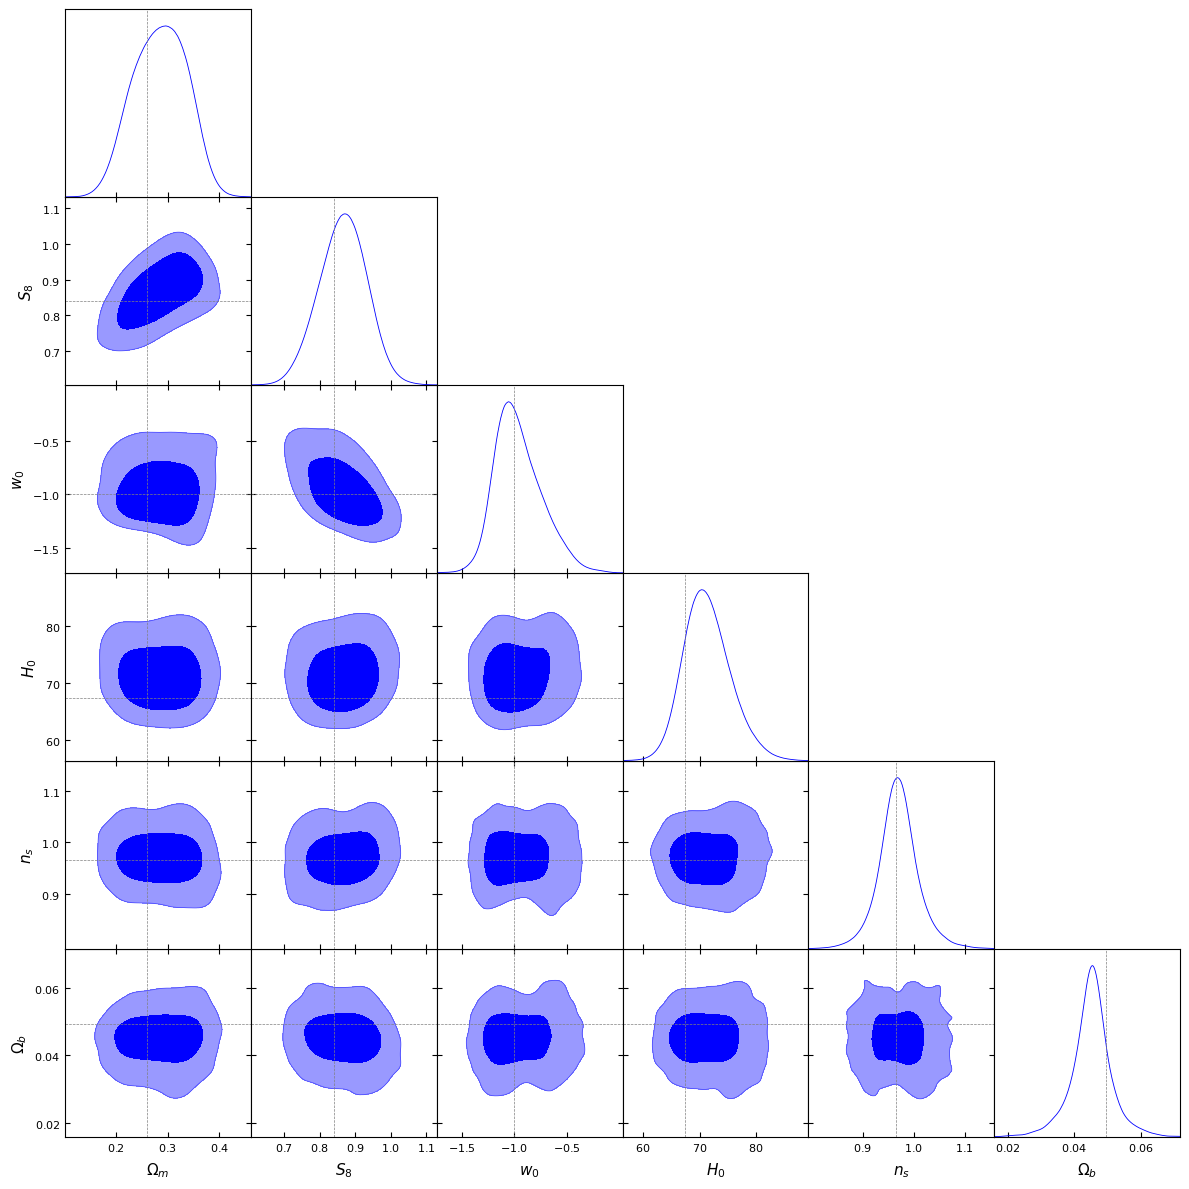

In [60]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale4 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

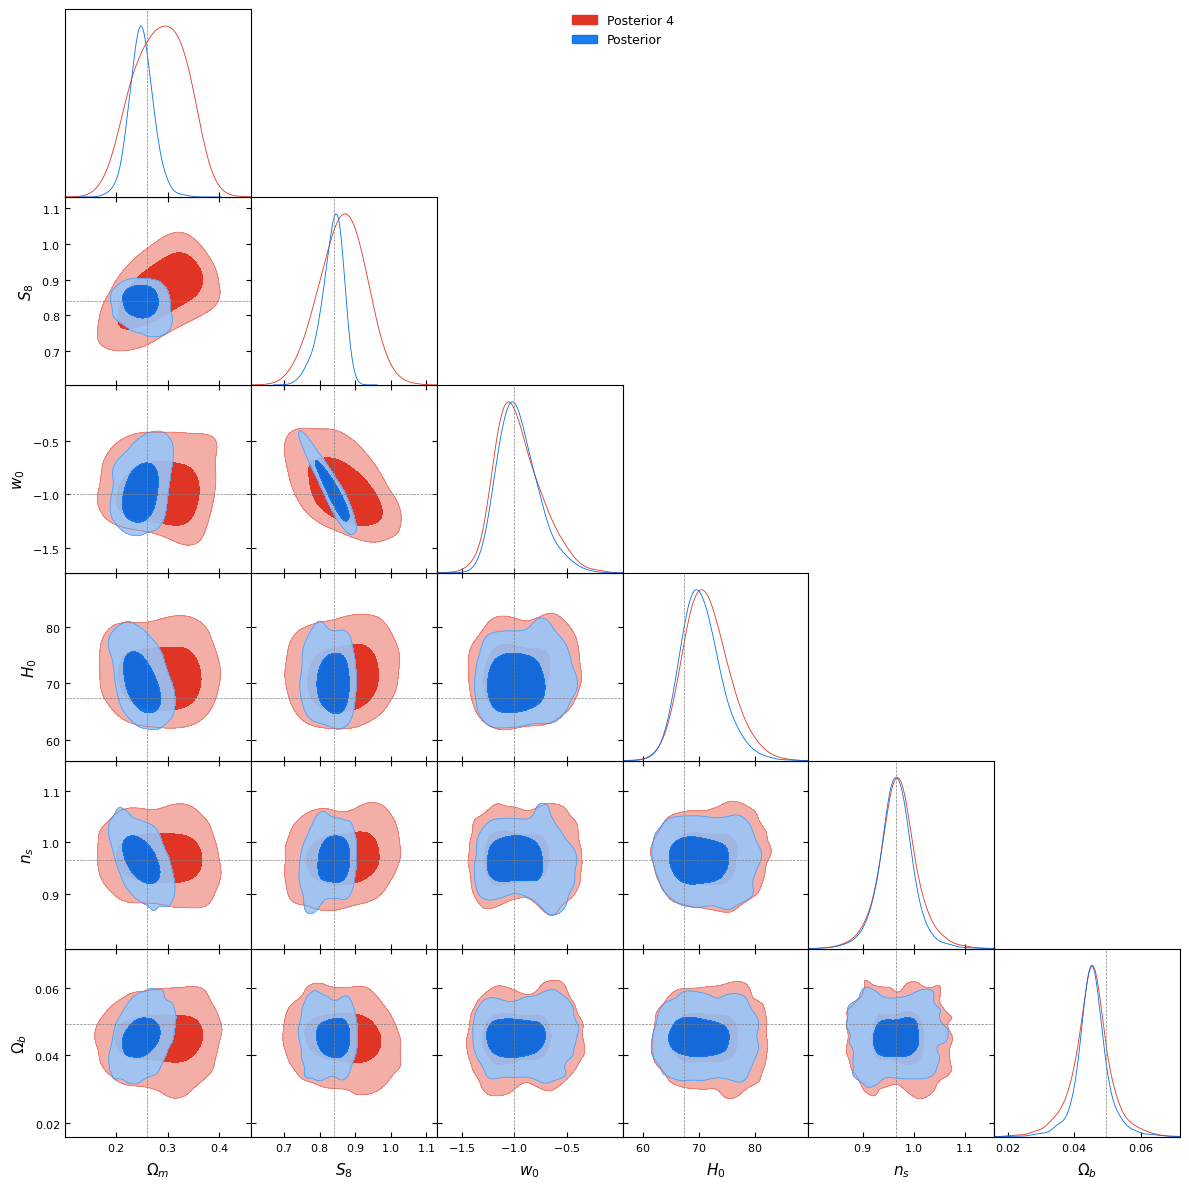

In [61]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.9

g.triangle_plot([samples_gd_scale4, samples_gd], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## Scale 5

In [62]:
l1_scale5 = l1_full[:, 4]
l1_scale5.shape 

(16965, 40)

In [63]:
params = jnp.array(params)
l1_scale5 = jnp.array(l1_scale5)
dataset = (params, l1_scale5)

In [64]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [65]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin2_scale5"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -5.122/ Best val loss -5.136:   8%|▊         | 80/1000 [00:30<05:50,  2.62it/s]

Neural network training stopped after 81 epochs.
Early stopping with best validation metric: -5.136047840118408
Best model saved at epoch 60
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.2288818359375
[!] Validation loss: -5.136047840118408
[!] Test loss: -5.125154972076416


In [67]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [68]:
fid_mean_scale5 = fid_mean[4]
fid_mean_scale5.shape

(40,)

Sampling

In [69]:
import jax.random as random

master_key = random.PRNGKey(1)

In [70]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale5, num_samples=num_samples, key=sample_key
)

In [71]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [72]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


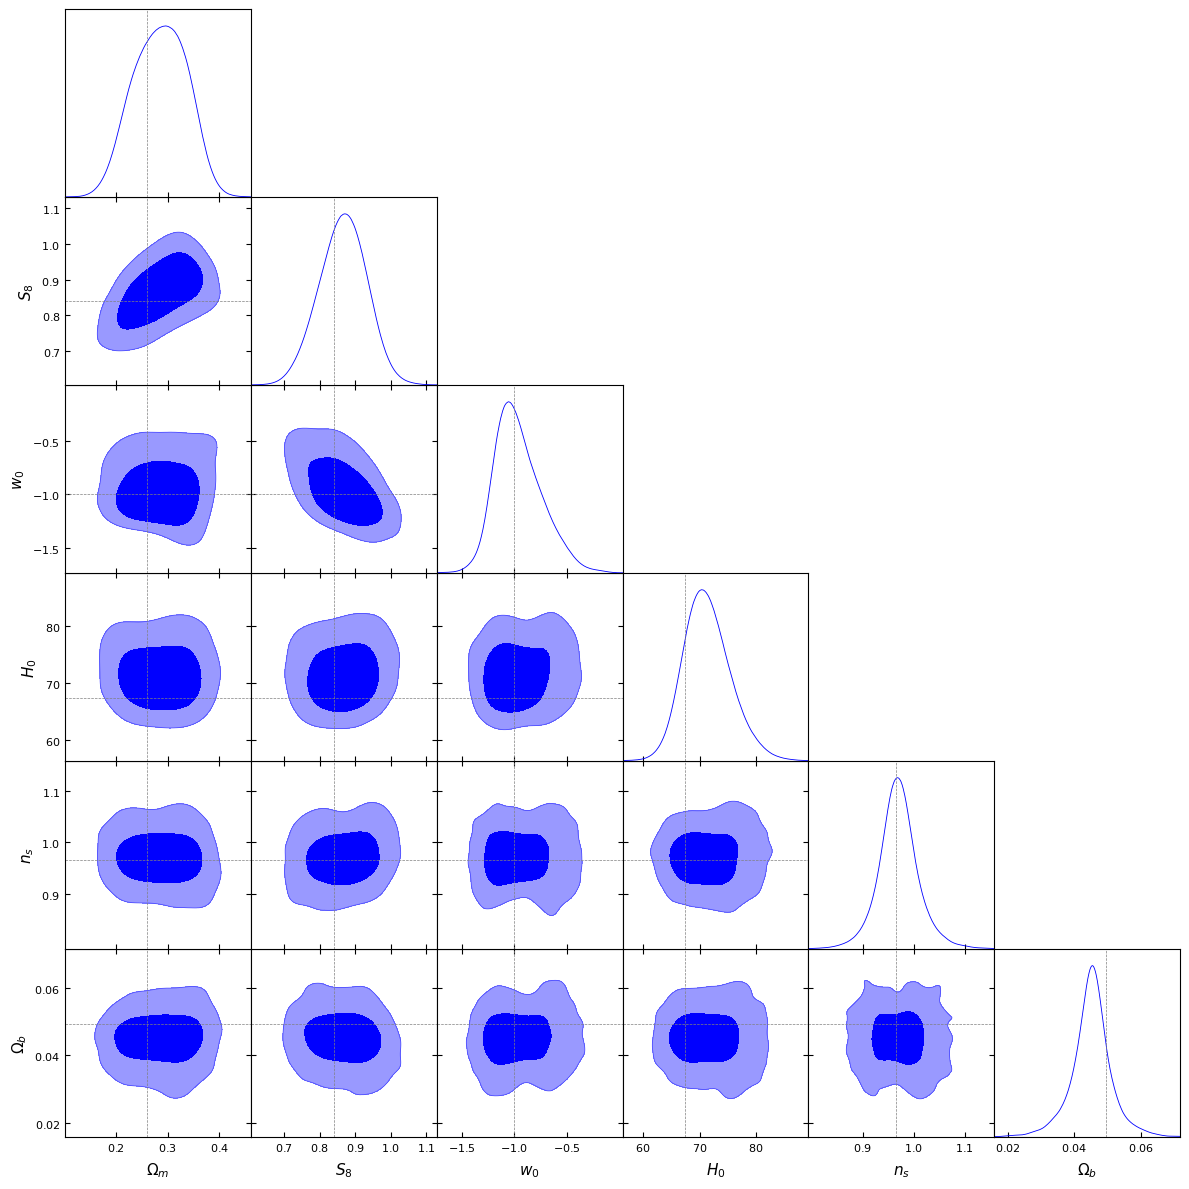

In [73]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale5 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

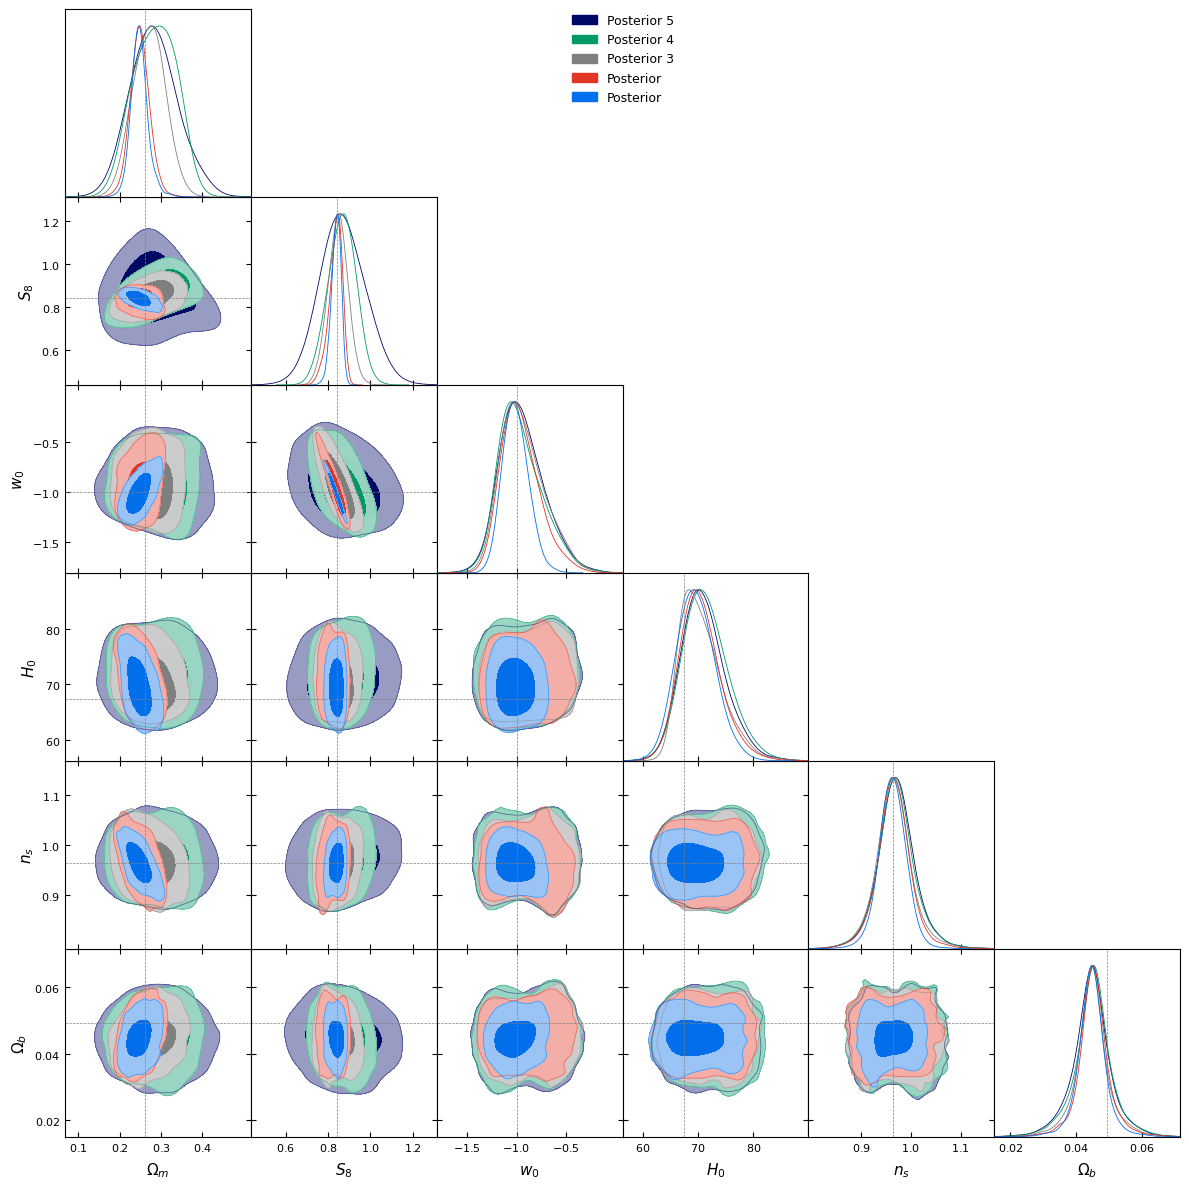

In [74]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_gd_scale5, samples_gd_scale4, samples_gd_scale3, samples_gd, samples_gd_scale1], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

In [75]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin2_npe.npy", samples_gd_scale1.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin2_npe.npy", samples_gd.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin2_npe.npy", samples_gd_scale3.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin2_npe.npy", samples_gd_scale4.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin2_npe.npy", samples_gd_scale5.samples)

In [13]:
samples1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin2_npe.npy")
samples2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin2_npe.npy")
samples3 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin2_npe.npy")
samples4 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin2_npe.npy")
samples5 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin2_npe.npy")
samples = [samples1, samples2, samples3, samples4, samples5]

In [14]:
samples_scale = []
for i in range(5):
    samples_scale_i = MCSamples(samples=samples[i], names=labels, label=f"Posterior {i+1}")
    samples_scale.append(samples_scale_i)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


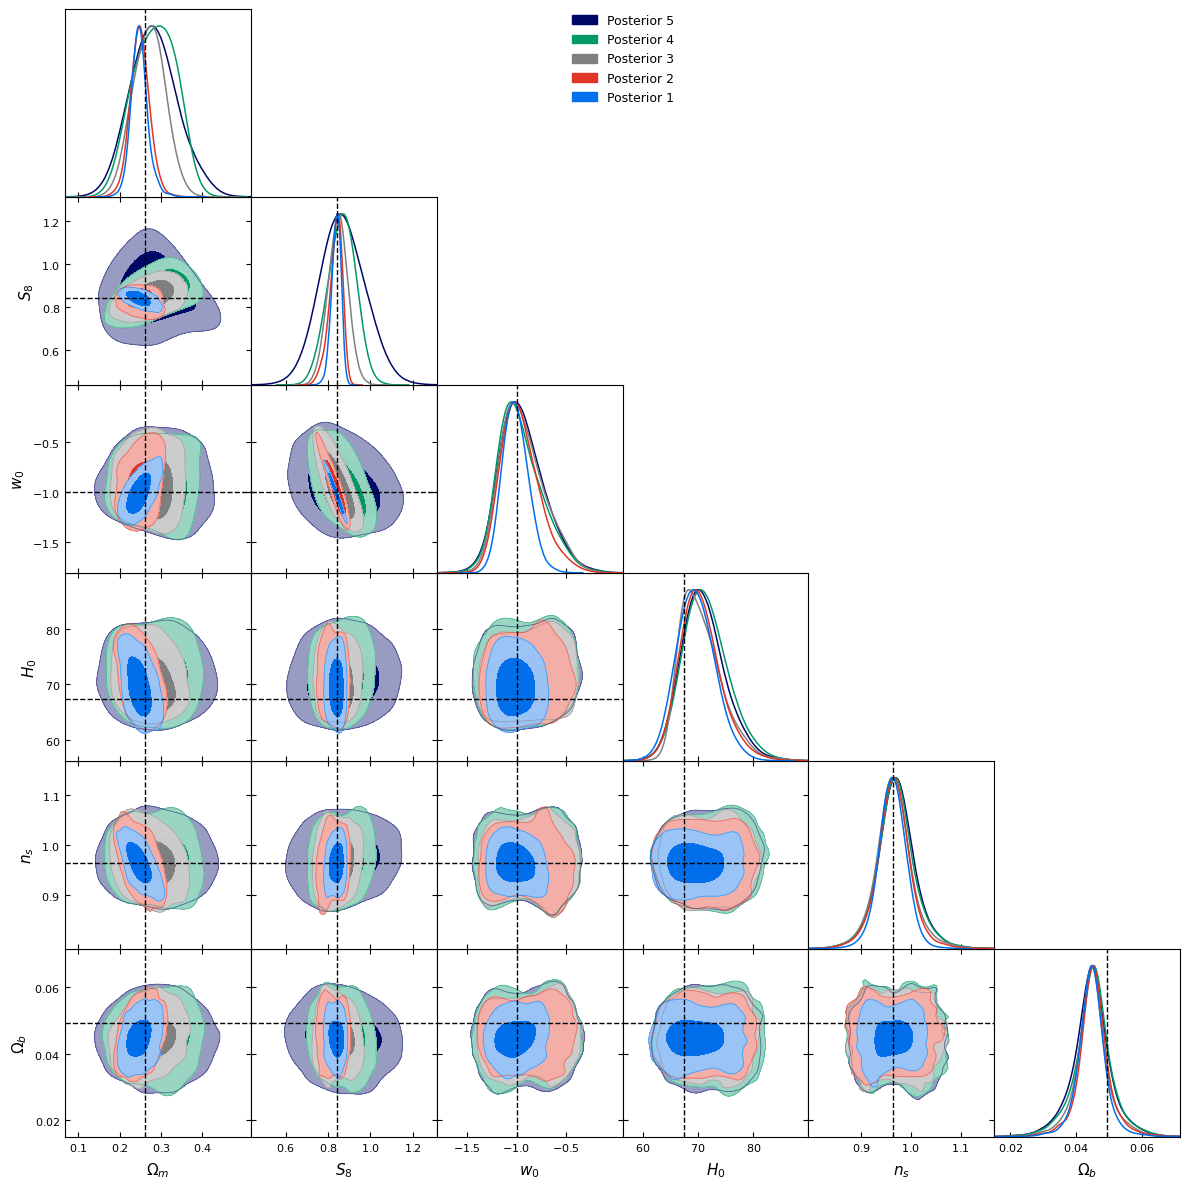

In [15]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[4], samples_scale[3], samples_scale[2], samples_scale[1], samples_scale[0]], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
# plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_each_scale_bin2_npe.pdf")
plt.show()

# **BIN 3**

In [25]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin3.npy', allow_pickle=True)

In [26]:
params.shape, l1_full.shape

((16965, 6), (16965, 5, 40))

## Scale 1

In [5]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16965, 40)

In [6]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [7]:
dataset = (params, l1_scale1)

In [8]:
inference = NPE()

In [9]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [10]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin3_scale1"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.


[!] Creating the Trainer module.
Could not tabulate model: 


[!] Training the density estimator.


Epochs: Val loss -10.893/ Best val loss -10.952:  15%|█▌        | 154/1000 [00:57<05:14,  2.69it/s]

Neural network training stopped after 155 epochs.
Early stopping with best validation metric: -10.951998710632324
Best model saved at epoch 134
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -10.986363410949707
[!] Validation loss: -10.951998710632324
[!] Test loss: -10.87376880645752


In [11]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [14]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin3.npy', allow_pickle=True)

In [15]:
np.array(fid_full).shape

(200, 5, 40)

In [16]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [17]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [18]:
import jax.random as random

master_key = random.PRNGKey(1)

In [19]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [20]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [21]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


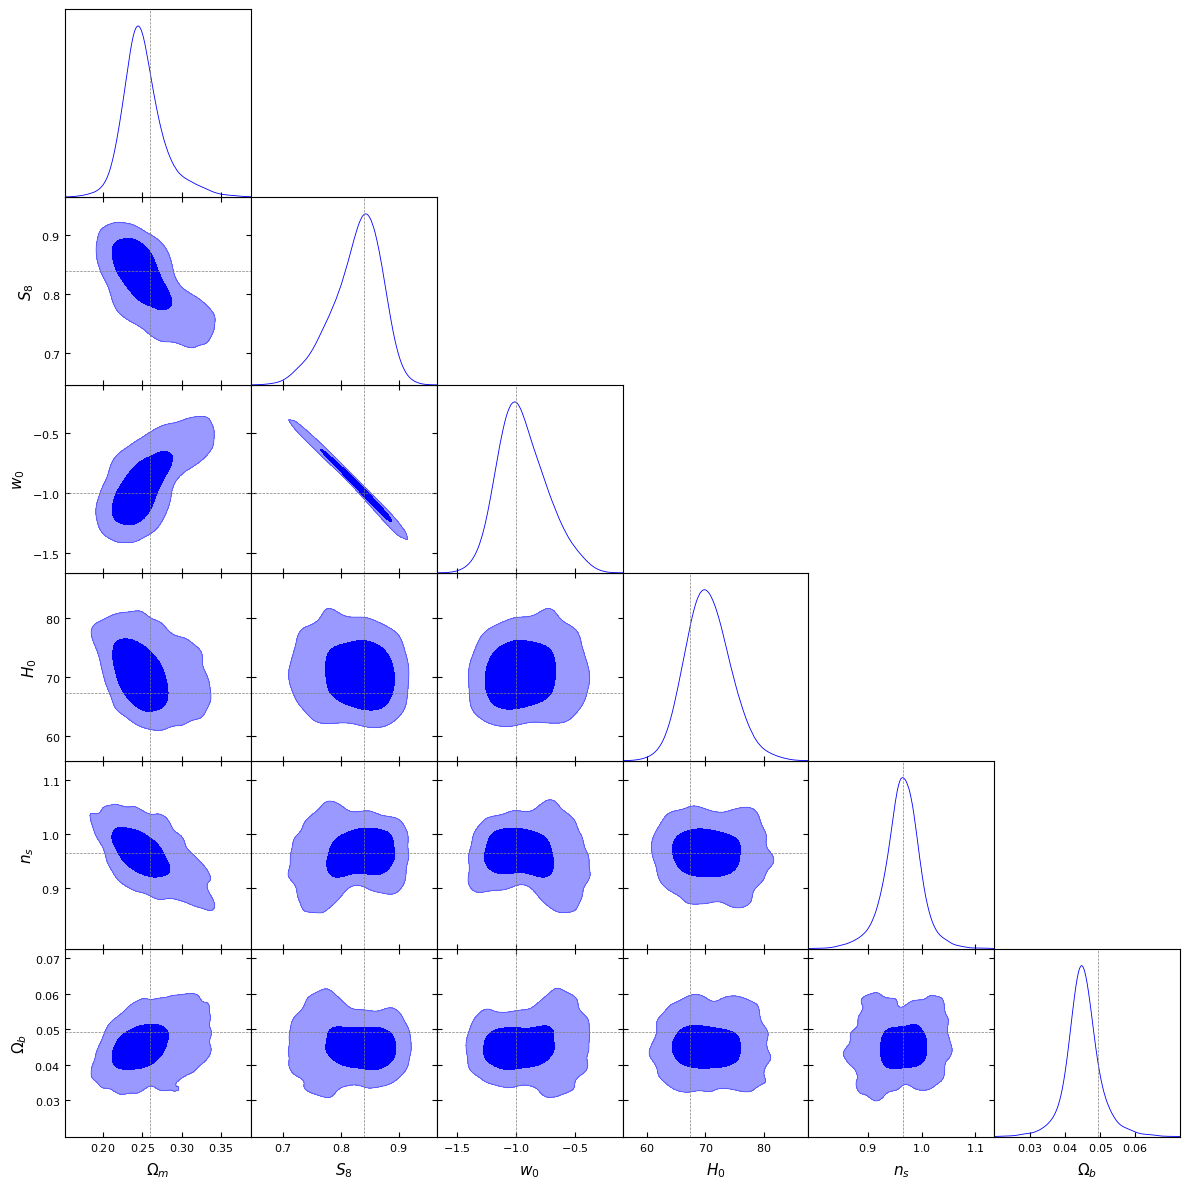

In [22]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 2

In [84]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [85]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)
dataset = (params, l1_scale2)

In [86]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [87]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin3_scale2"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -8.311/ Best val loss -8.317:  16%|█▋        | 165/1000 [00:56<04:43,  2.94it/s]

Neural network training stopped after 166 epochs.
Early stopping with best validation metric: -8.31654167175293
Best model saved at epoch 161
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.353212356567383
[!] Validation loss: -8.316590309143066
[!] Test loss: -8.28721809387207


In [88]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [89]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin3.npy', allow_pickle=True)

In [90]:
np.array(fid_full).shape

(200, 5, 40)

In [91]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [92]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [93]:
import jax.random as random

master_key = random.PRNGKey(1)

In [94]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [95]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [96]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


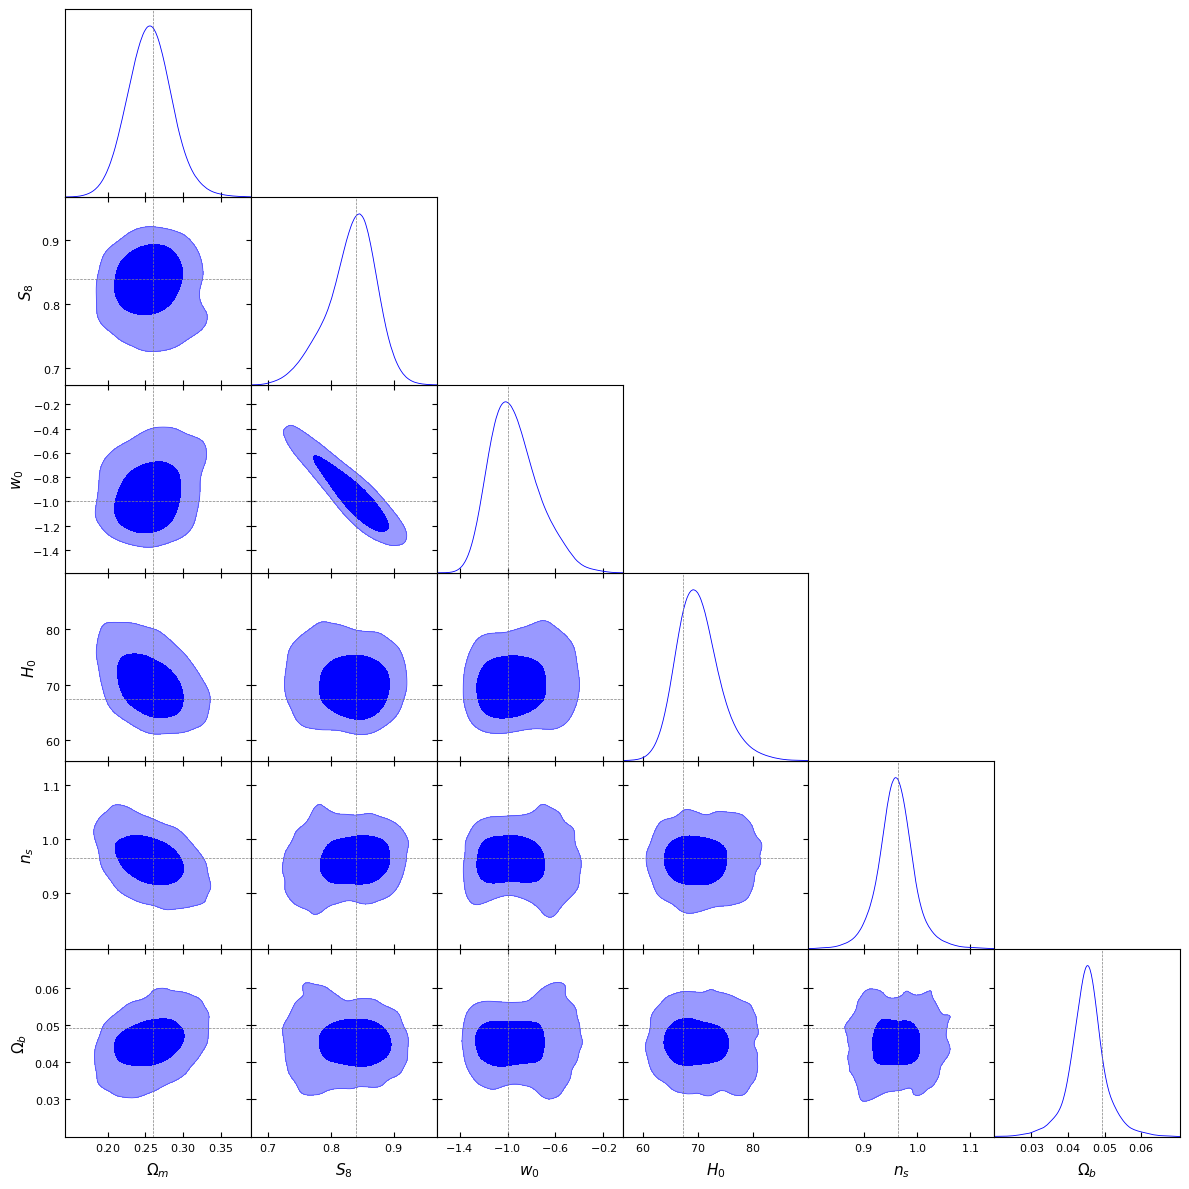

In [97]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 3

In [98]:
l1_scale3 = l1_full[:, 2]
l1_scale3.shape 

(16965, 40)

In [99]:
params = jnp.array(params)
l1_scale3 = jnp.array(l1_scale3)
dataset = (params, l1_scale3)

In [102]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [103]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin3_scale3"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -6.726/ Best val loss -6.775:  13%|█▎        | 127/1000 [00:45<05:11,  2.80it/s]

Neural network training stopped after 128 epochs.
Early stopping with best validation metric: -6.774911880493164
Best model saved at epoch 107
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.921977519989014
[!] Validation loss: -6.774911880493164
[!] Test loss: -6.8267717361450195


In [104]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [105]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin3.npy', allow_pickle=True)

In [106]:
np.array(fid_full).shape

(200, 5, 40)

In [107]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [108]:
fid_mean_scale3 = fid_mean[2]
fid_mean_scale3.shape

(40,)

Sampling

In [109]:
import jax.random as random

master_key = random.PRNGKey(1)

In [110]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale3, num_samples=num_samples, key=sample_key
)

In [111]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [112]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


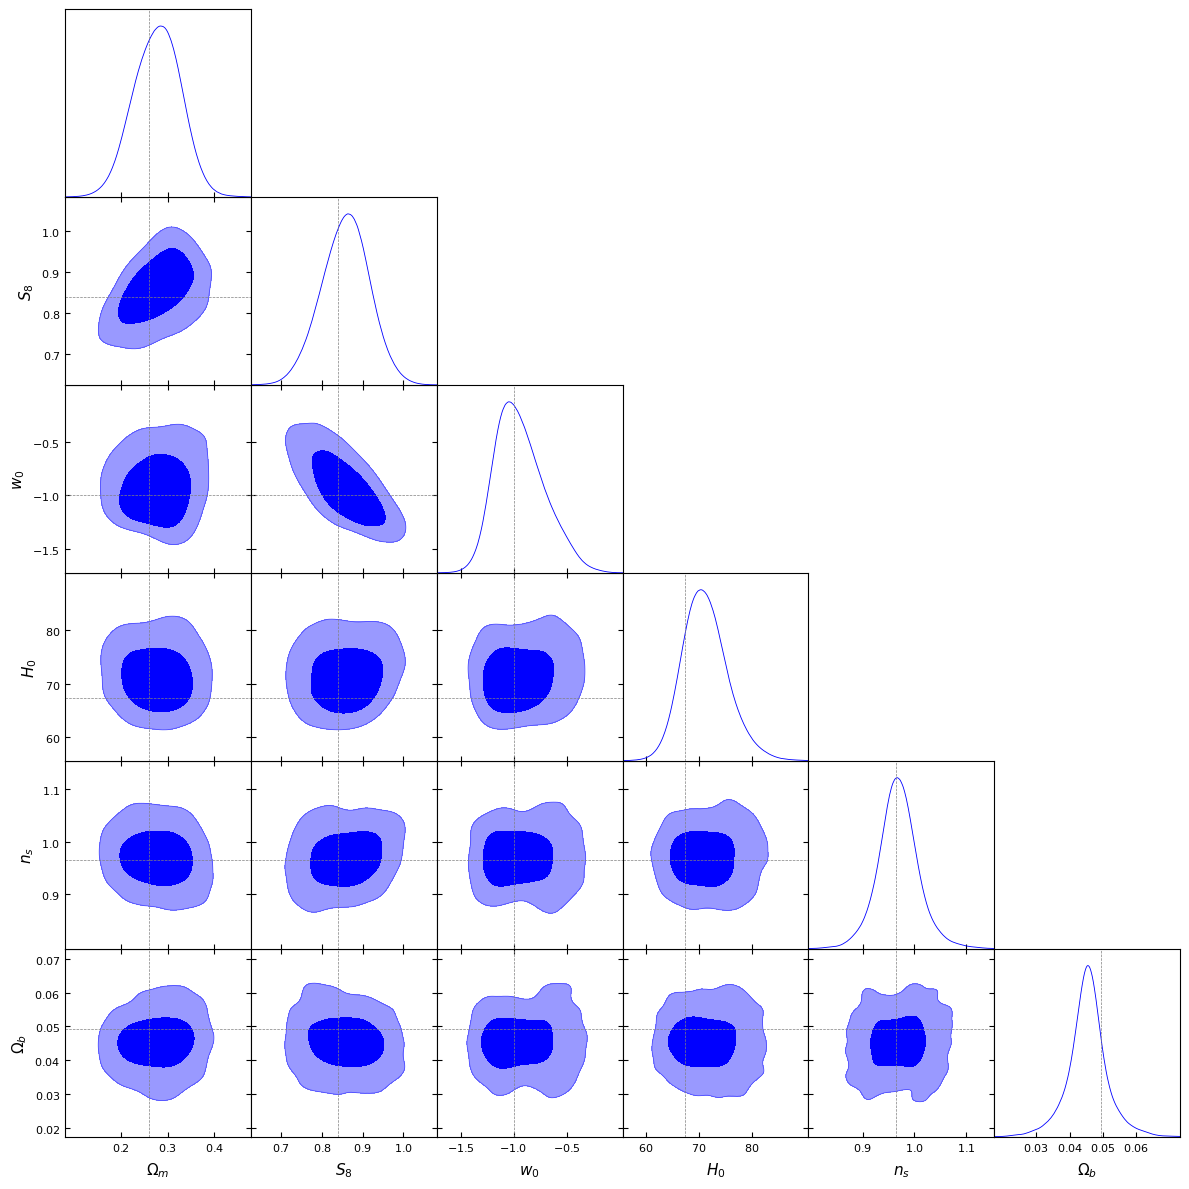

In [113]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

Removed no burn in


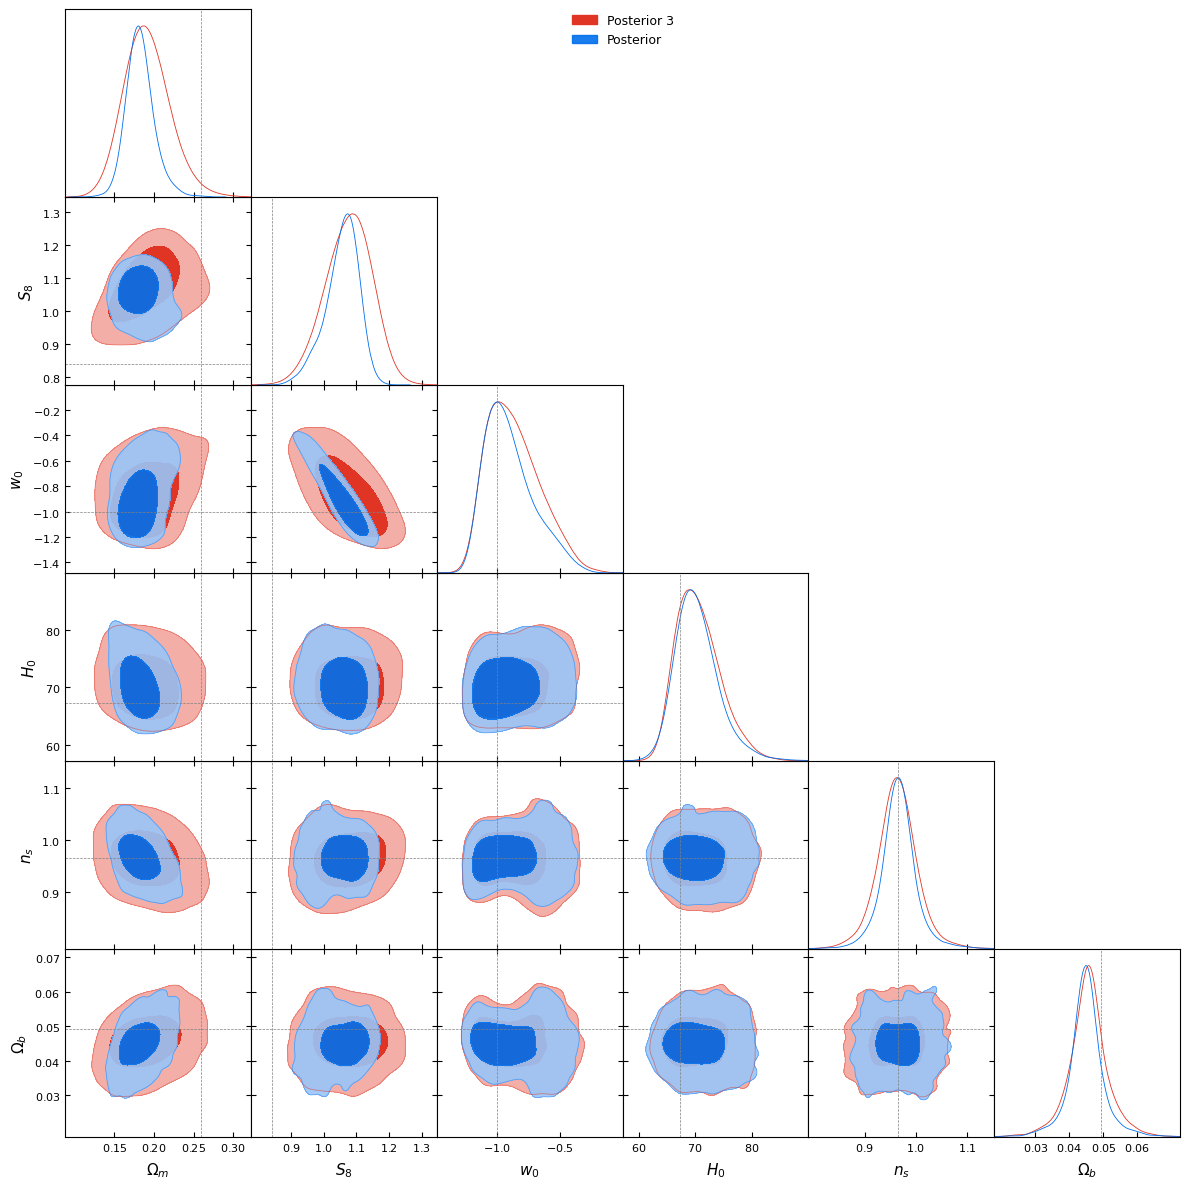

In [54]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 3",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.9

g.triangle_plot([samples_gd_scale3, samples_gd], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 4

In [114]:
l1_scale4 = l1_full[:, 3]
l1_scale4.shape 

(16965, 40)

In [115]:
params = jnp.array(params)
l1_scale4 = jnp.array(l1_scale4)
dataset = (params, l1_scale4)

In [116]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [117]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin3_scale4"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -5.755/ Best val loss -5.772:  13%|█▎        | 126/1000 [00:43<04:58,  2.92it/s]

Neural network training stopped after 127 epochs.
Early stopping with best validation metric: -5.772274017333984
Best model saved at epoch 108
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.891415596008301
[!] Validation loss: -5.773252487182617
[!] Test loss: -5.774223327636719


In [118]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [119]:
fid_mean_scale4 = fid_mean[3]
fid_mean_scale4.shape

(40,)

Sampling

In [120]:
import jax.random as random

master_key = random.PRNGKey(1)

In [121]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale4, num_samples=num_samples, key=sample_key
)

In [122]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [123]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


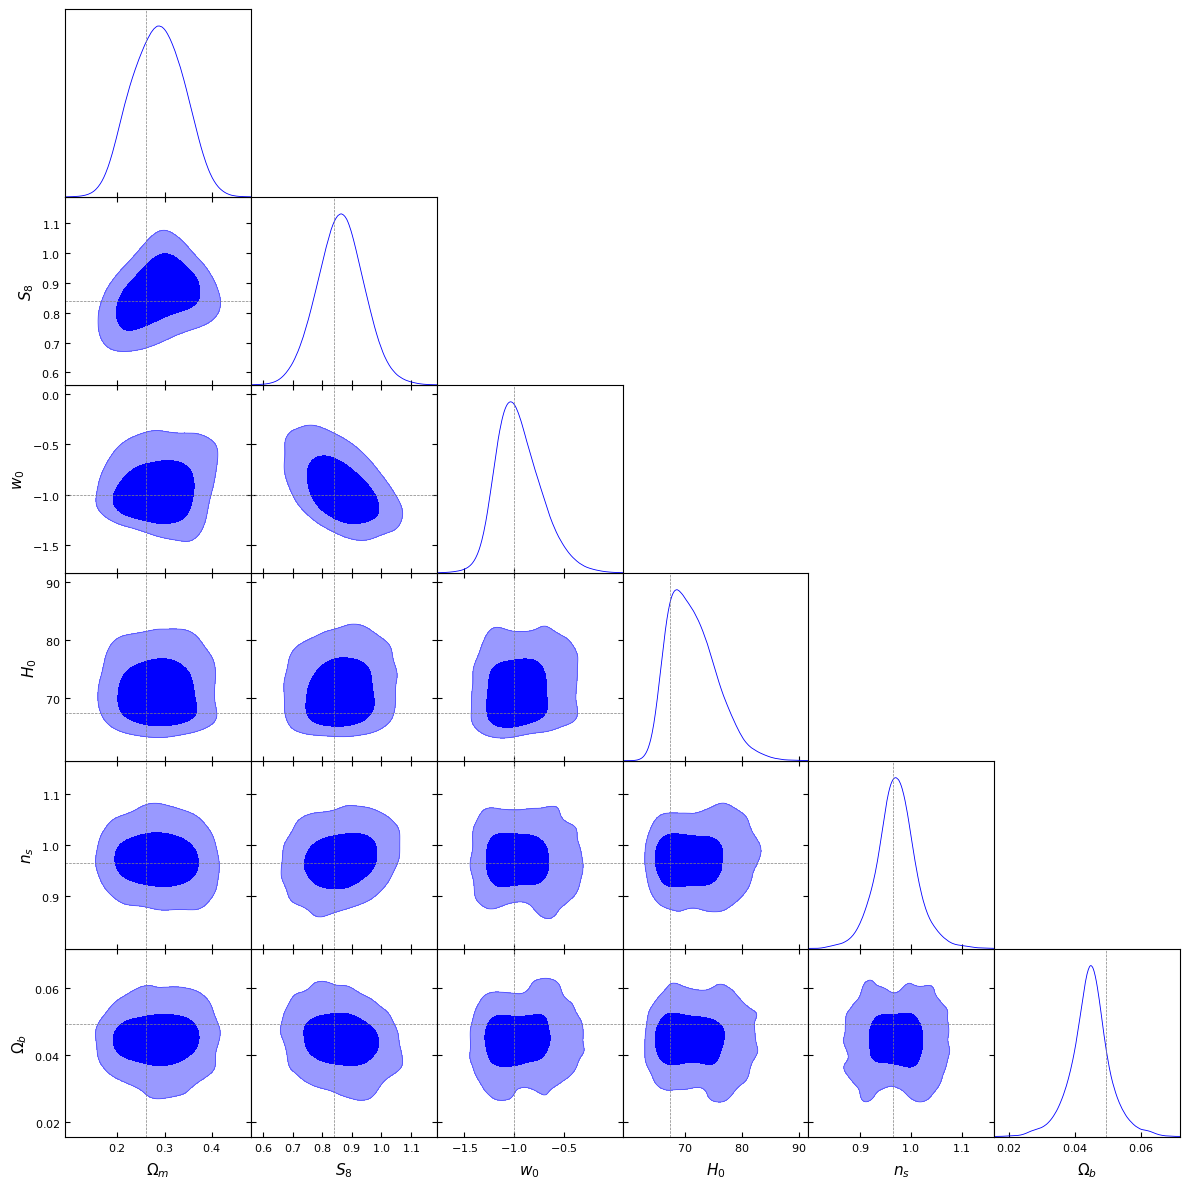

In [124]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale4 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

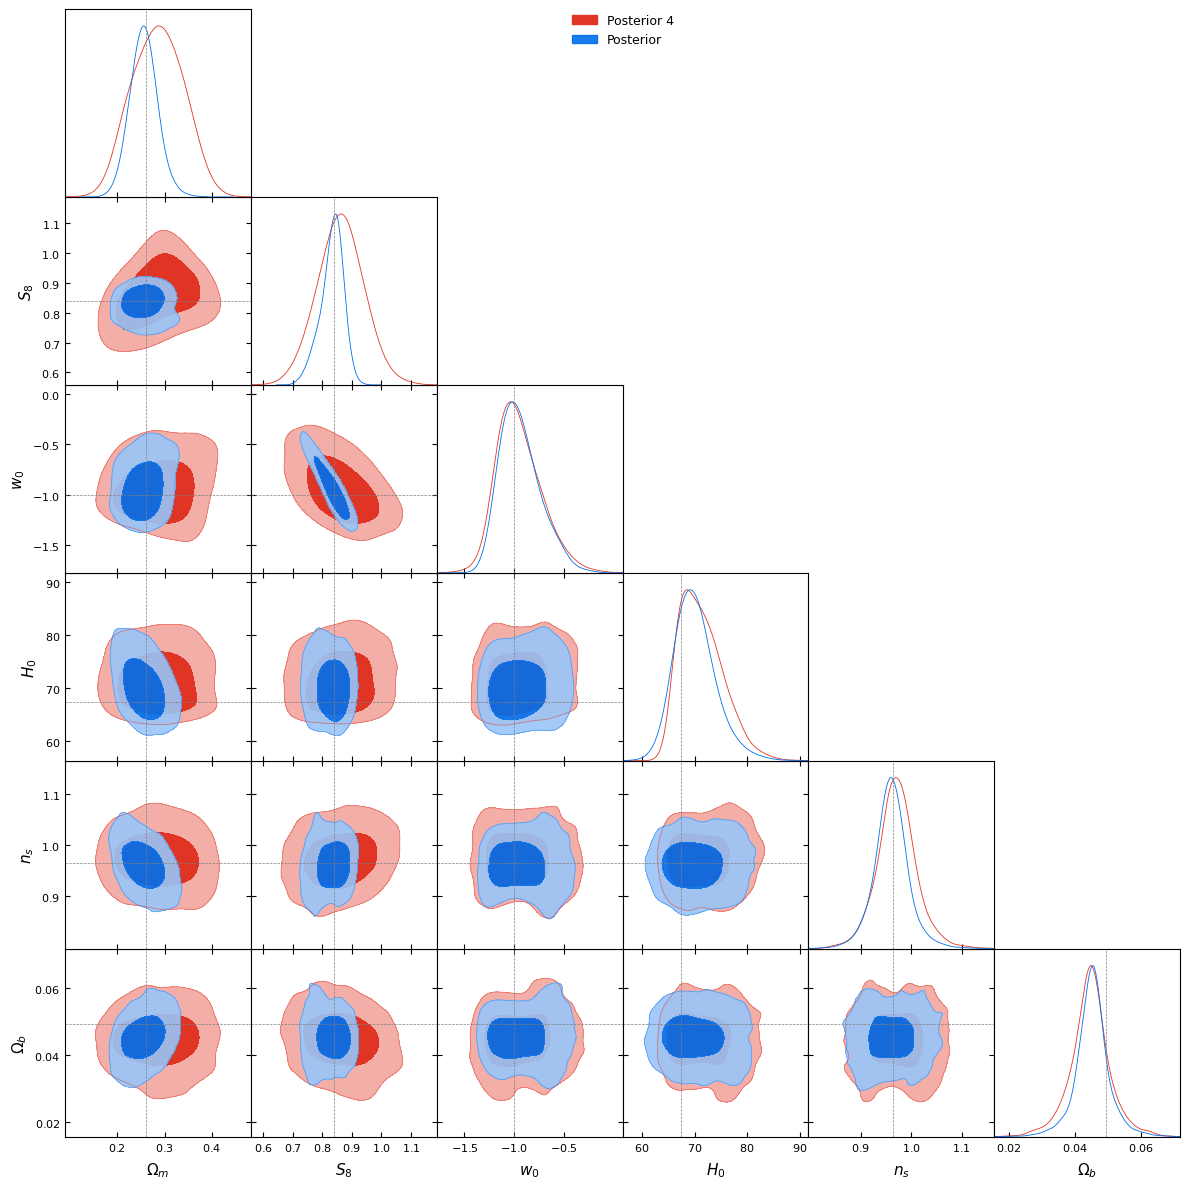

In [125]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.9

g.triangle_plot([samples_gd_scale4, samples_gd], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })
plt.show()

## Scale 5

In [27]:
l1_scale5 = l1_full[:, 4]
l1_scale5.shape 

(16965, 40)

In [32]:
params = jnp.array(params)
l1_scale5 = jnp.array(l1_scale5)
dataset = (params, l1_scale5)

In [33]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [34]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin3_scale5"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss nan/ Best val loss nan:   2%|▏         | 21/1000 [00:10<07:51,  2.08it/s]

Neural network training stopped after 22 epochs.
Early stopping with best validation metric: nan
Best model saved at epoch 1
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: nan
[!] Validation loss: nan
[!] Test loss: nan


In [130]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [131]:
fid_mean_scale5 = fid_mean[4]
fid_mean_scale5.shape

(40,)

Sampling

In [132]:
import jax.random as random

master_key = random.PRNGKey(1)

In [133]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale5, num_samples=num_samples, key=sample_key
)

In [6]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [10]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


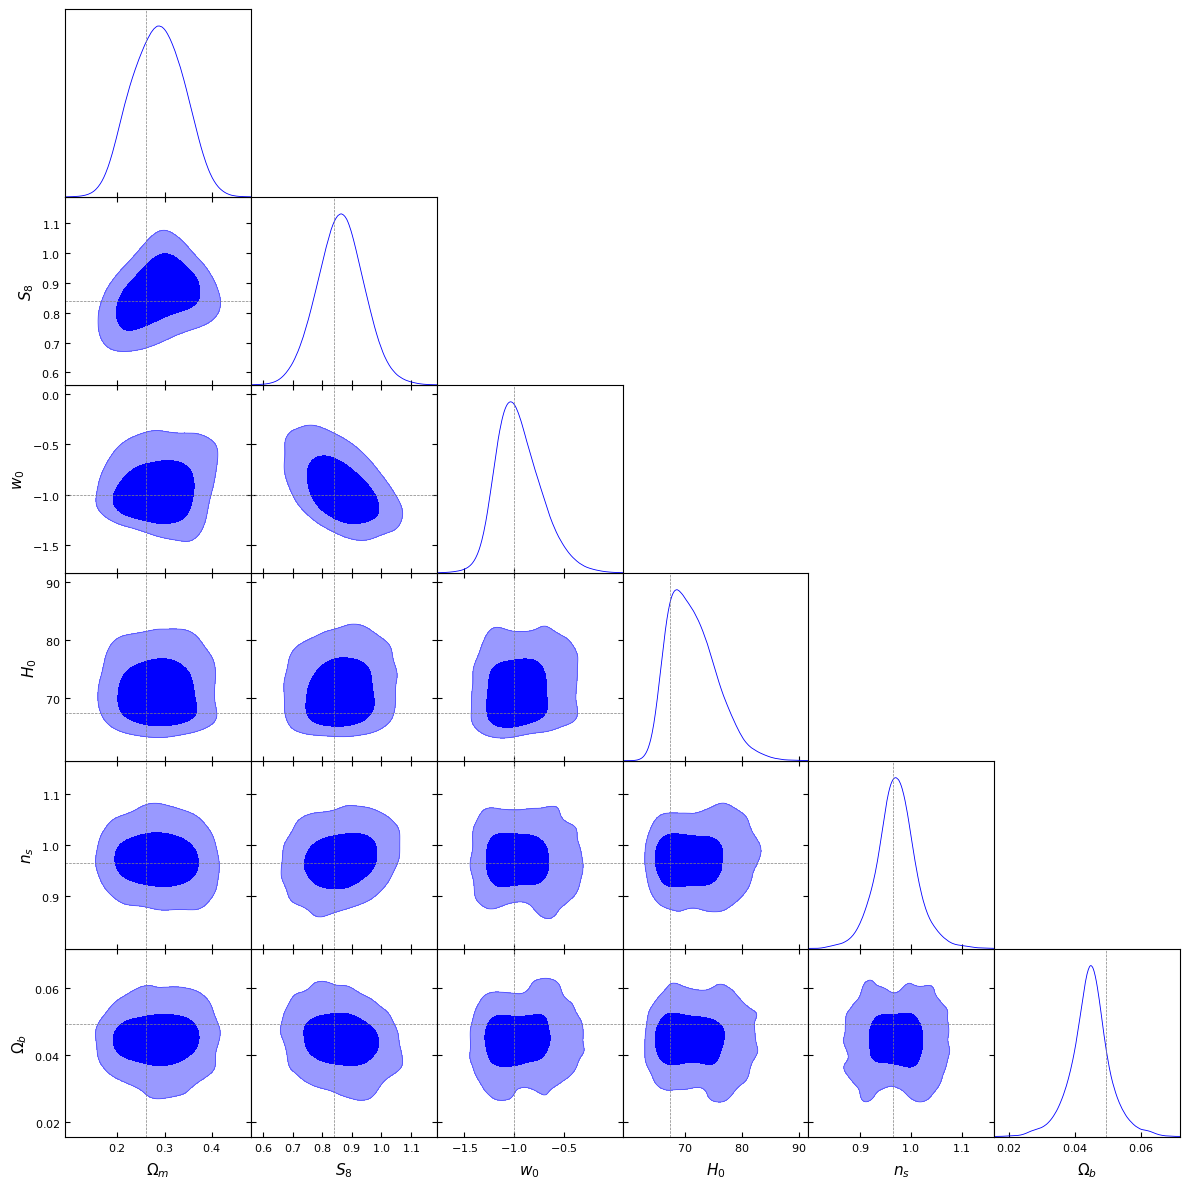

In [136]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale5 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [137]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin3_npe.npy", samples_gd_scale1.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin3_npe.npy", samples_gd.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin3_npe.npy", samples_gd_scale3.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin3_npe.npy", samples_gd_scale4.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin3_npe.npy", samples_gd_scale5.samples)

In [16]:
samples1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin3_npe.npy")
samples2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin3_npe.npy")
samples3 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin3_npe.npy")
samples4 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin3_npe.npy")
samples5 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin3_npe.npy")
samples = [samples1, samples2, samples3, samples4, samples5]

In [17]:
samples_scale = []
for i in range(5):
    samples_scale_i = MCSamples(samples=samples[i], names=labels, label=f"Posterior {i+1}")
    samples_scale.append(samples_scale_i)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [9]:
samples_scale[0]

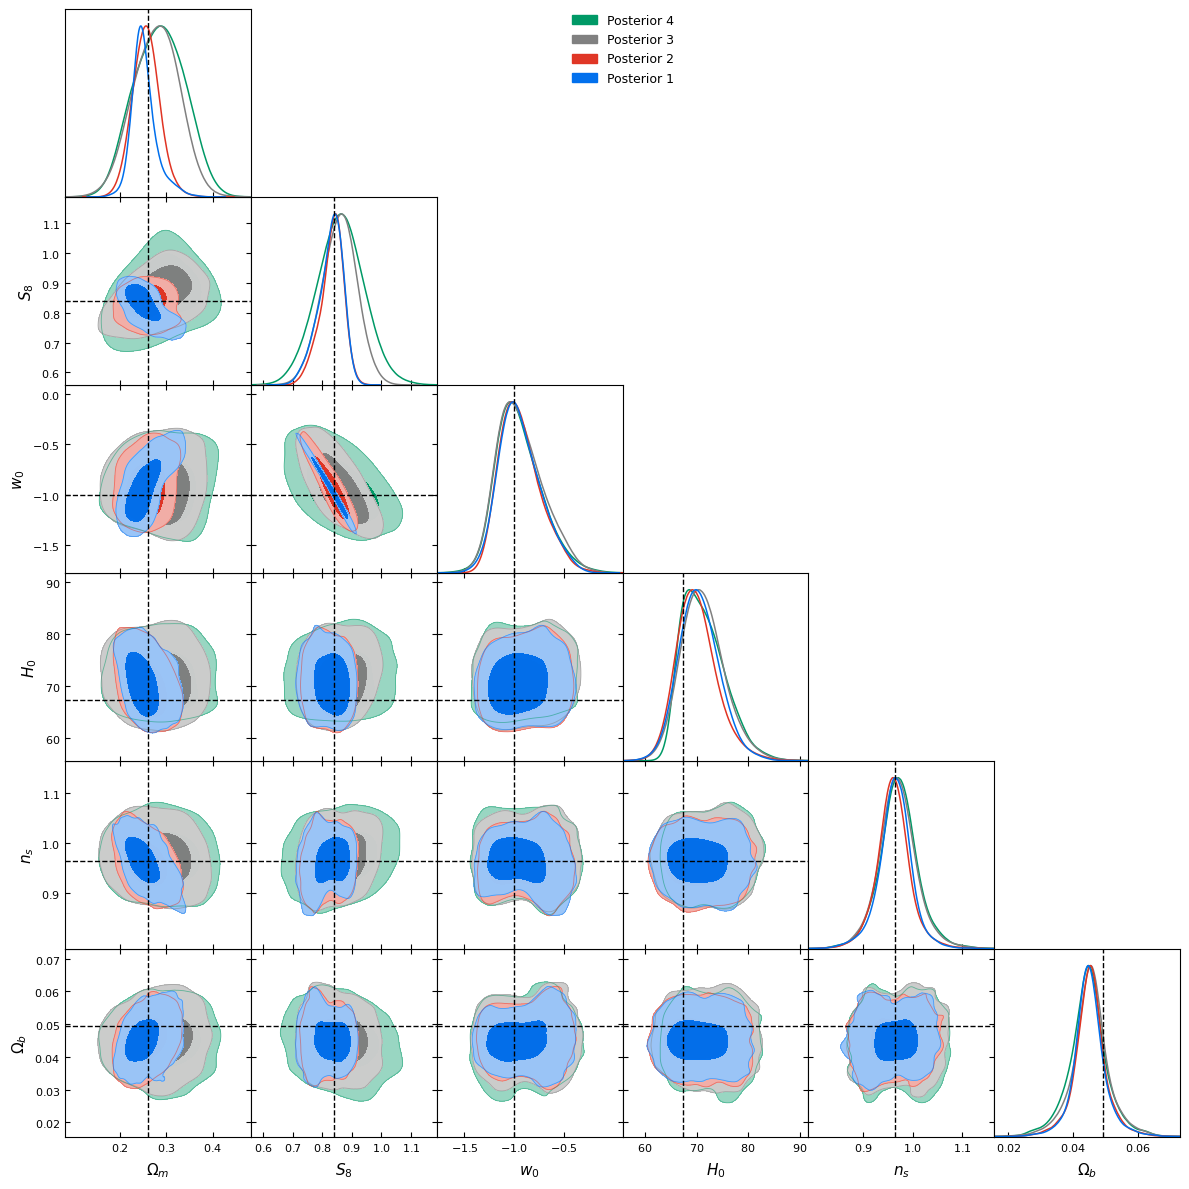

In [35]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[3], samples_scale[2], samples_scale[1], samples_scale[0]], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_each_scale_bin3_npe.pdf")
plt.show()

# **BIN 3**

In [41]:
l1_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/grid/all_l1_norms_bin4.npy', allow_pickle=True)

In [42]:
params.shape, l1_full.shape

((16965, 6), (16965, 5, 40))

## Scale 1

In [43]:
l1_scale1 = l1_full[:, 0]
l1_scale1.shape 

(16965, 40)

In [44]:
params = jnp.array(params)
l1_scale1 = jnp.array(l1_scale1)

In [45]:
dataset = (params, l1_scale1)

In [46]:
inference = NPE()

In [47]:
inference = inference.append_simulations(params, l1_scale1)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [48]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin4_scale1"
#Turn it into an absolute path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -10.774/ Best val loss -10.821:  19%|█▉        | 190/1000 [01:05<04:38,  2.91it/s]

Neural network training stopped after 191 epochs.
Early stopping with best validation metric: -10.821027755737305
Best model saved at epoch 170
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -10.917125701904297
[!] Validation loss: -10.821027755737305
[!] Test loss: -10.725831031799316


In [49]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [50]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin4.npy', allow_pickle=True)

In [51]:
np.array(fid_full).shape

(200, 5, 40)

In [52]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [53]:
fid_mean_scale1 = fid_mean[0]
fid_mean_scale1.shape

(40,)

Sampling

In [54]:
import jax.random as random

master_key = random.PRNGKey(1)

In [55]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale1, num_samples=num_samples, key=sample_key
)

In [56]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [57]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


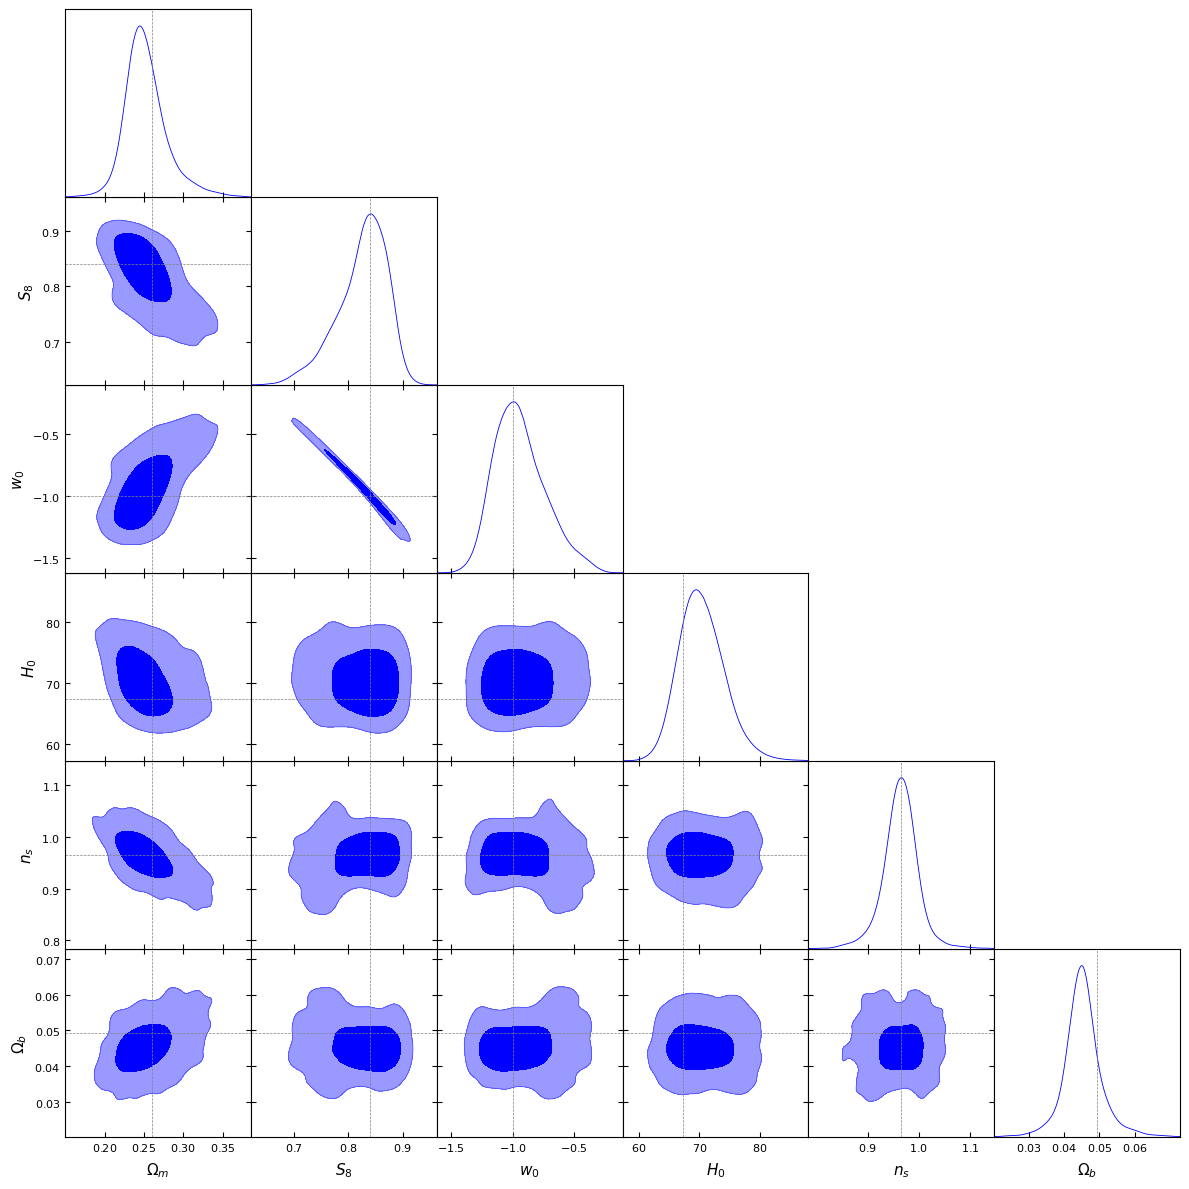

In [58]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale1 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale1], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 2

In [59]:
l1_scale2 = l1_full[:, 1]
l1_scale2.shape 

(16965, 40)

In [60]:
params = jnp.array(params)
l1_scale2 = jnp.array(l1_scale2)
dataset = (params, l1_scale2)

In [61]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale2)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [62]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin4_scale2"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -8.022/ Best val loss -8.035:  15%|█▌        | 151/1000 [00:51<04:51,  2.92it/s]

Neural network training stopped after 152 epochs.
Early stopping with best validation metric: -8.035265922546387
Best model saved at epoch 131
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -8.010720252990723
[!] Validation loss: -8.035265922546387
[!] Test loss: -8.008650779724121


In [63]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [65]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin4.npy', allow_pickle=True)

In [66]:
np.array(fid_full).shape

(200, 5, 40)

In [67]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [68]:
fid_mean_scale2 = fid_mean[1]
fid_mean_scale2.shape

(40,)

Sampling

In [69]:
import jax.random as random

master_key = random.PRNGKey(1)

In [70]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale2, num_samples=num_samples, key=sample_key
)

In [71]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [72]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


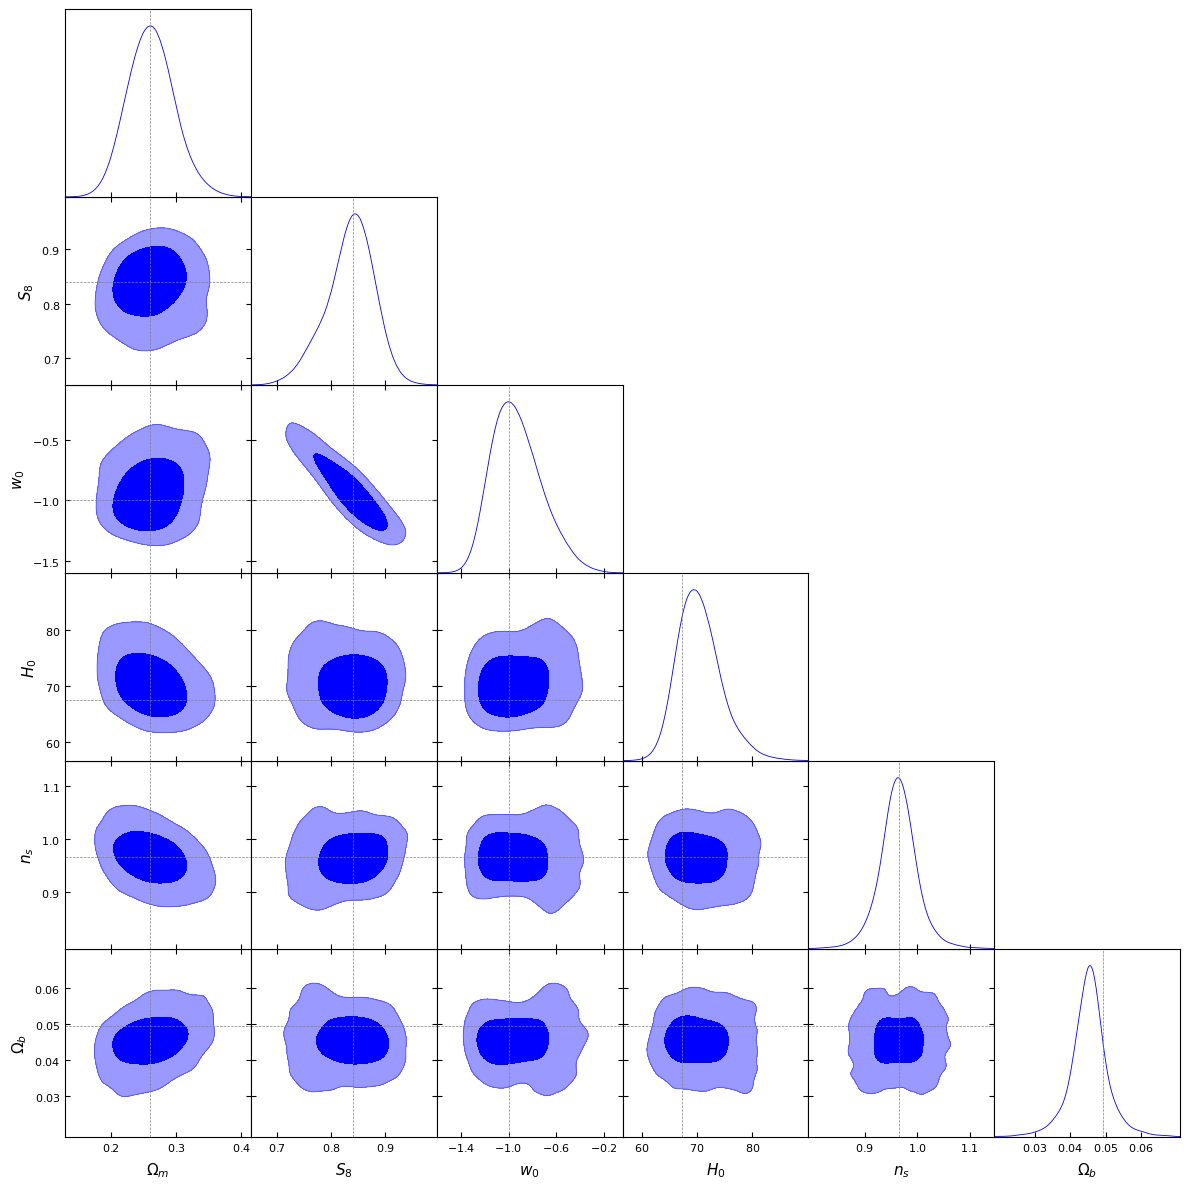

In [73]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 3

In [74]:
l1_scale3 = l1_full[:, 2]
l1_scale3.shape 

(16965, 40)

In [75]:
params = jnp.array(params)
l1_scale3 = jnp.array(l1_scale3)
dataset = (params, l1_scale3)

In [76]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale3)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [77]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin4_scale3"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -6.634/ Best val loss -6.644:  14%|█▍        | 140/1000 [00:47<04:51,  2.95it/s]

Neural network training stopped after 141 epochs.
Early stopping with best validation metric: -6.643787384033203
Best model saved at epoch 120
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -6.689733028411865
[!] Validation loss: -6.643787384033203
[!] Test loss: -6.386383533477783


In [78]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [79]:
fid_full = np.load('/home/tersenov/CosmoGridV1/stage3_forecast/fiducial/cosmo_fiducial/all_l1_norms_fid_bin4.npy', allow_pickle=True)

In [80]:
np.array(fid_full).shape

(200, 5, 40)

In [81]:
fid_mean = np.mean(fid_full, axis=0)
fid_full.shape, fid_mean.shape

((200, 5, 40), (5, 40))

In [82]:
fid_mean_scale3 = fid_mean[2]
fid_mean_scale3.shape

(40,)

Sampling

In [83]:
import jax.random as random

master_key = random.PRNGKey(1)

In [84]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale3, num_samples=num_samples, key=sample_key
)

In [85]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [86]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


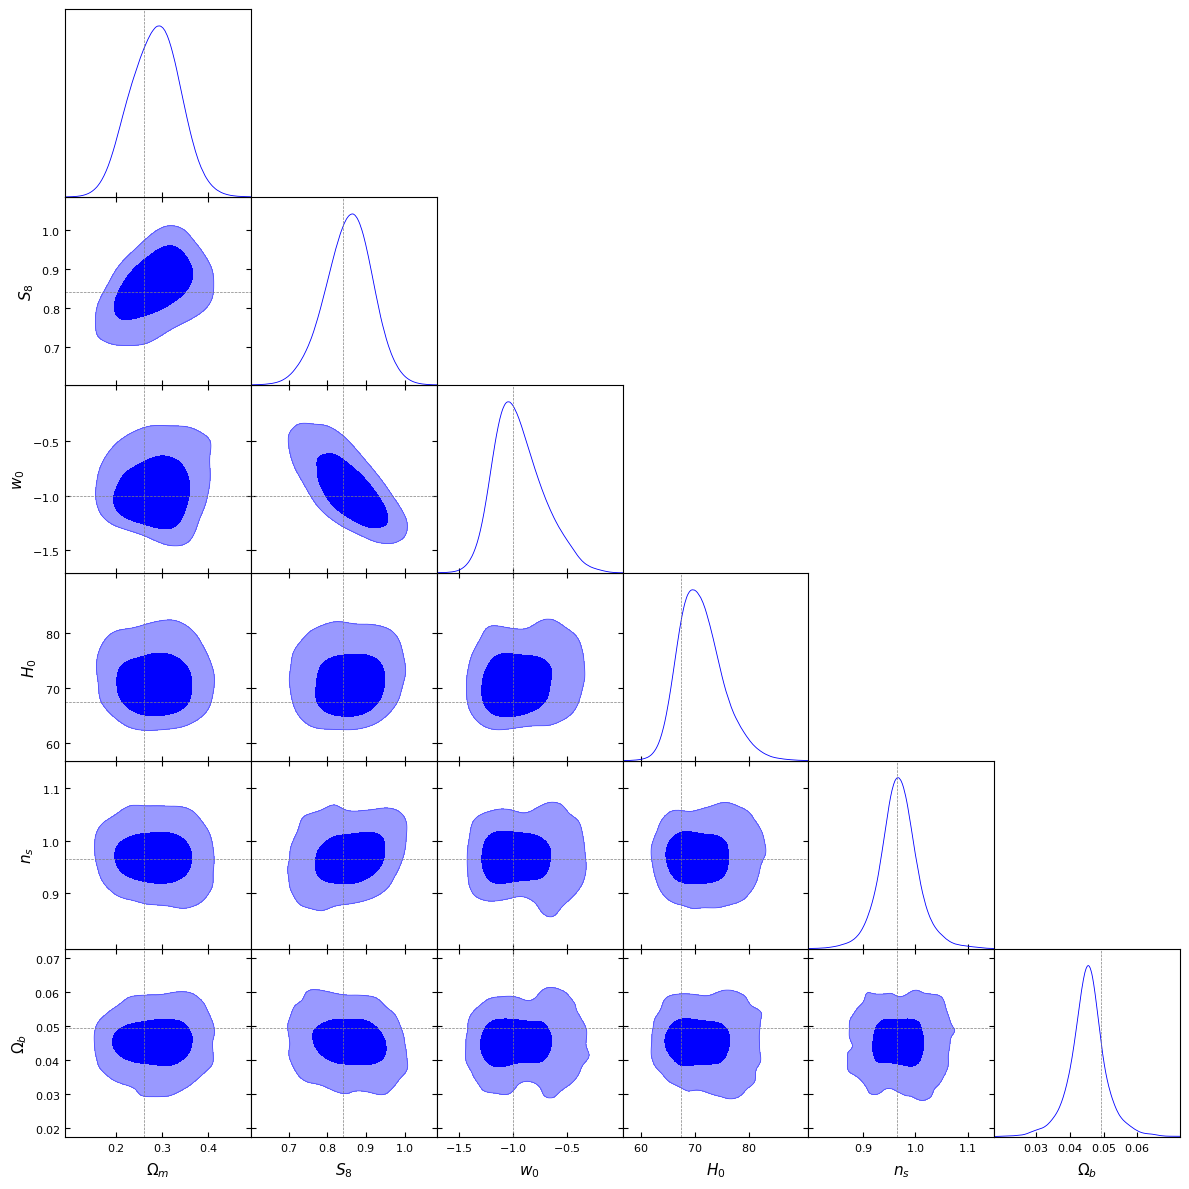

In [87]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale3 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale3], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 4

In [89]:
l1_scale4 = l1_full[:, 3]
l1_scale4.shape 

(16965, 40)

In [90]:
params = jnp.array(params)
l1_scale4 = jnp.array(l1_scale4)
dataset = (params, l1_scale4)

In [91]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale4)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [92]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin4_scale4"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss -5.547/ Best val loss -5.563:   8%|▊         | 80/1000 [00:30<05:47,  2.65it/s]

Neural network training stopped after 81 epochs.
Early stopping with best validation metric: -5.562520503997803
Best model saved at epoch 60
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: -5.590807914733887
[!] Validation loss: -5.562520503997803
[!] Test loss: -5.576539039611816


In [93]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [94]:
fid_mean_scale4 = fid_mean[3]
fid_mean_scale4.shape

(40,)

Sampling

In [95]:
import jax.random as random

master_key = random.PRNGKey(1)

In [96]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale4, num_samples=num_samples, key=sample_key
)

In [97]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [98]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


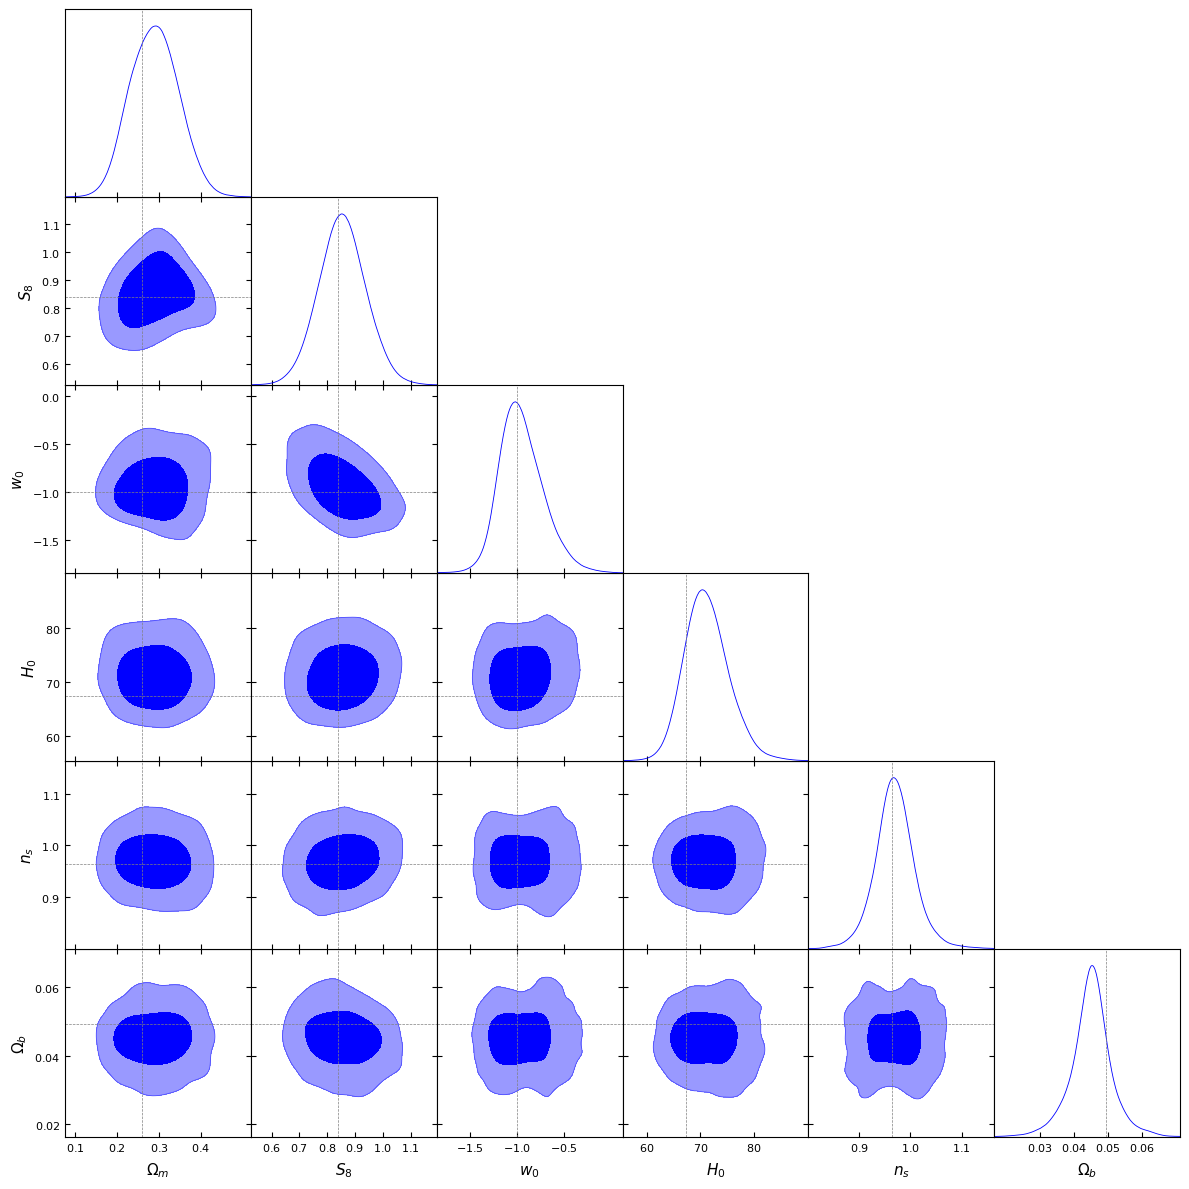

In [99]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale4 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 4",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

## Scale 5

In [101]:
l1_scale5 = l1_full[:, 4]
l1_scale5.shape 

(16965, 40)

In [102]:
params = jnp.array(params)
l1_scale5 = jnp.array(l1_scale5)
dataset = (params, l1_scale5)

In [103]:
inference = NPE()
inference = inference.append_simulations(params, l1_scale5)
inference._train_dataset

[!] Inputs are valid.
[!] Appending 16965 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 11875 simulations.
[!] Validation set: 3393 simulations.
[!] Test set: 1697 simulations.


In [104]:
#Specify a checkpoint to save the weights of the neural network
CHECKPOINT_PATH = "./cosmoGRID_weights_bin4_scale5"
#Turn it into an absolut path
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

num_epochs = 1000

metrics, density_estimator = inference.train(
    checkpoint_path=CHECKPOINT_PATH,
    num_epochs=num_epochs,
    learning_rate=2e-4,
    training_batch_size = 40
)

[!] Creating DataLoaders with batch_size 40.
[!] Building the neural network.
[!] Creating the Trainer module.
Could not tabulate model: 
[!] Training the density estimator.


Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epochs: Val loss nan/ Best val loss nan:   2%|▏         | 21/1000 [00:10<07:46,  2.10it/s]

Neural network training stopped after 22 epochs.
Early stopping with best validation metric: nan
Best model saved at epoch 1
Early stopping parameters: min_delta=0.001, patience=20


[!] Training loss: nan
[!] Validation loss: nan
[!] Test loss: nan


In [105]:
posterior = inference.build_posterior()

[!] Posterior $p(\theta| x)$ built. The class DirectPosterior is used to sample and evaluate the log probability.


Fiducial

In [106]:
fid_mean_scale5 = fid_mean[4]
fid_mean_scale5.shape

(40,)

Sampling

In [ ]:
import jax.random as random

master_key = random.PRNGKey(1)

In [ ]:
num_samples = 10_000
sample_key, master_key = jax.random.split(master_key)
samples = posterior.sample(
    x=fid_mean_scale5, num_samples=num_samples, key=sample_key
)

In [ ]:
#We will use getdist to visualise the results
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
%matplotlib inline

In [ ]:
true_params = jnp.array([[ 2.600e-01,  8.400e-01, -1.000e+00,  6.736e+01,  9.649e-01,
         4.930e-02]])

Removed no burn in


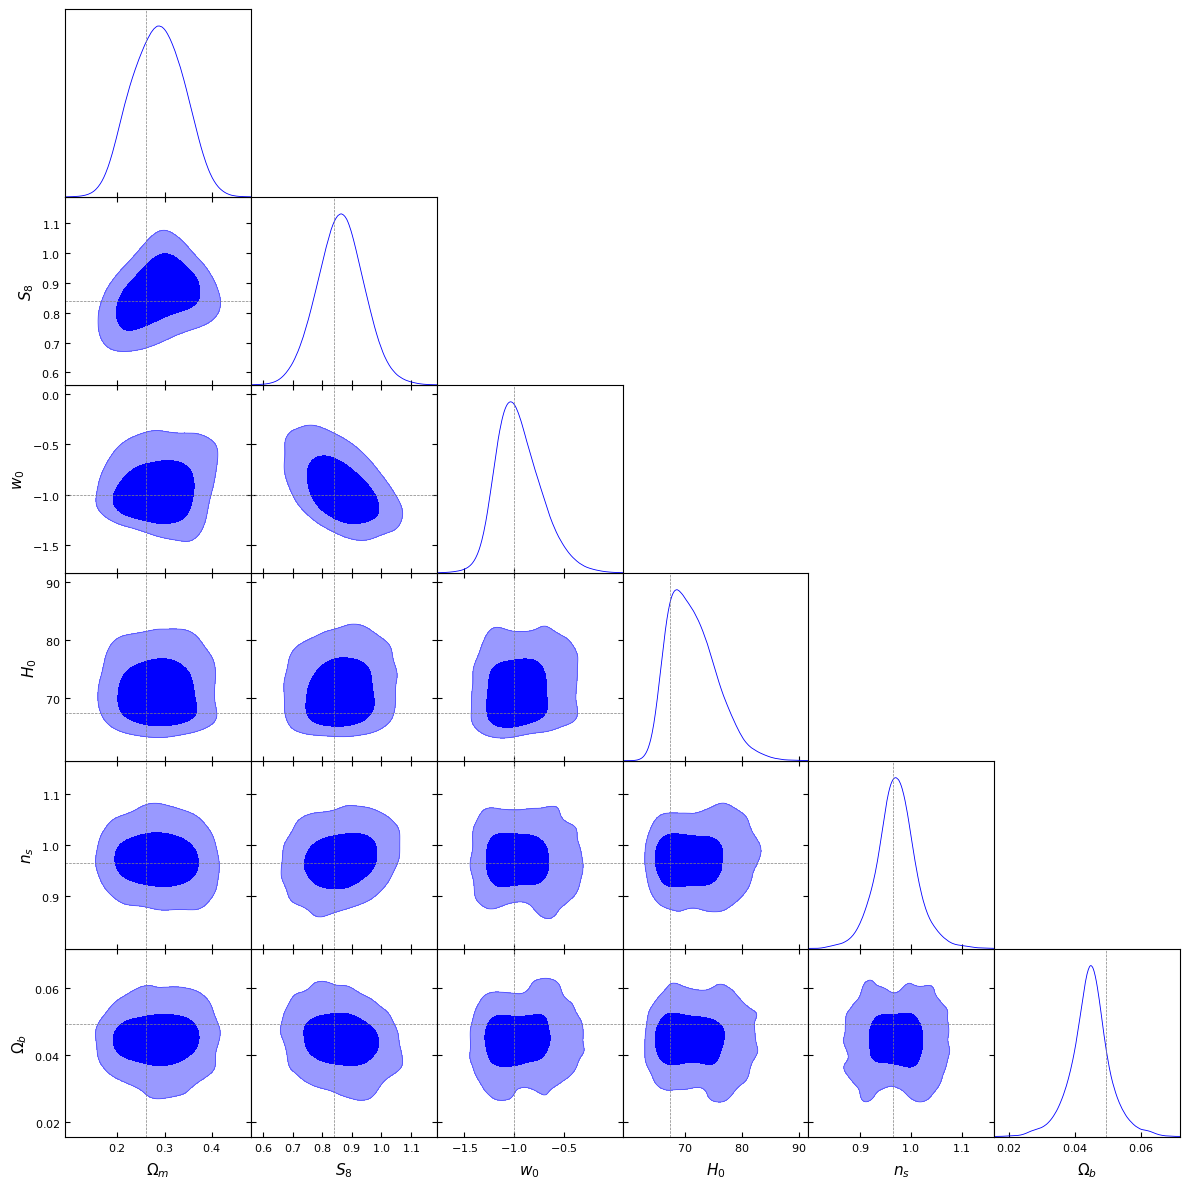

In [ ]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

samples_gd_scale5 = MCSamples(
    samples=samples,
    names=labels,
    label="Posterior 5",
)

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.4

g.triangle_plot([samples_gd_scale4], filled=True,
                line_args=[
                    {'color': 'blue'}
                ],
                contour_colors=['blue'],
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                })

plt.show()

In [107]:
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin4_npe.npy", samples_gd_scale1.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin4_npe.npy", samples_gd.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin4_npe.npy", samples_gd_scale3.samples)
np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin4_npe.npy", samples_gd_scale4.samples)
# np.save("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin4_npe.npy", samples_gd_scale5.samples)

In [108]:
samples1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin4_npe.npy")
samples2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale2_bin4_npe.npy")
samples3 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale3_bin4_npe.npy")
samples4 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale4_bin4_npe.npy")
# samples5 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale5_bin4_npe.npy")
samples = [samples1, samples2, samples3, samples4]

In [110]:
samples_scale = []
for i in range(4):
    samples_scale_i = MCSamples(samples=samples[i], names=labels, label=f"Posterior {i+1}")
    samples_scale.append(samples_scale_i)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [111]:
samples_scale[0]

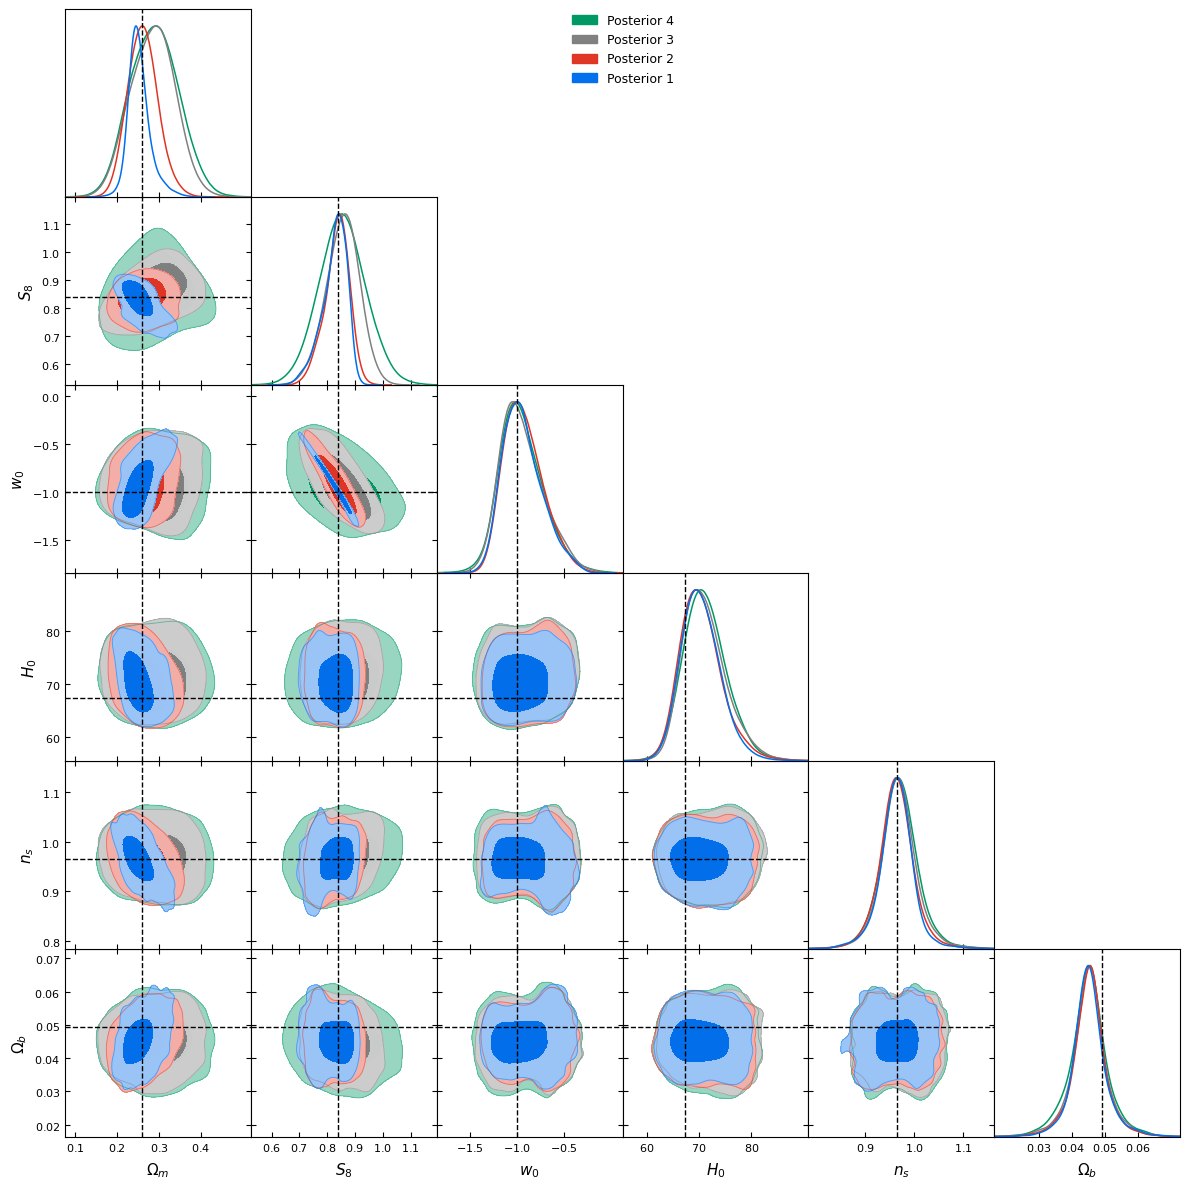

In [112]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples_scale[3], samples_scale[2], samples_scale[1], samples_scale[0]], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_each_scale_bin4_npe.pdf")
plt.show()

# Compare bin1, bin2, bin3, bin4

In [113]:
samples1_bin1 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin1_npe.npy")
samples1_bin2 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin2_npe.npy")
samples1_bin3 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin3_npe.npy")
samples1_bin4 = np.load("/home/tersenov/software/bar_impact/samples/posterior_samples_scale1_bin4_npe.npy")
samples = [samples1, samples2, samples3, samples4]

In [114]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]
samples1_bin1 = MCSamples(samples=samples1_bin1, names=labels, label=f"Posterior bin 1")
samples1_bin2 = MCSamples(samples=samples1_bin2, names=labels, label=f"Posterior bin 2")
samples1_bin3 = MCSamples(samples=samples1_bin3, names=labels, label=f"Posterior bin 3")
samples1_bin4 = MCSamples(samples=samples1_bin4, names=labels, label=f"Posterior bin 4")

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


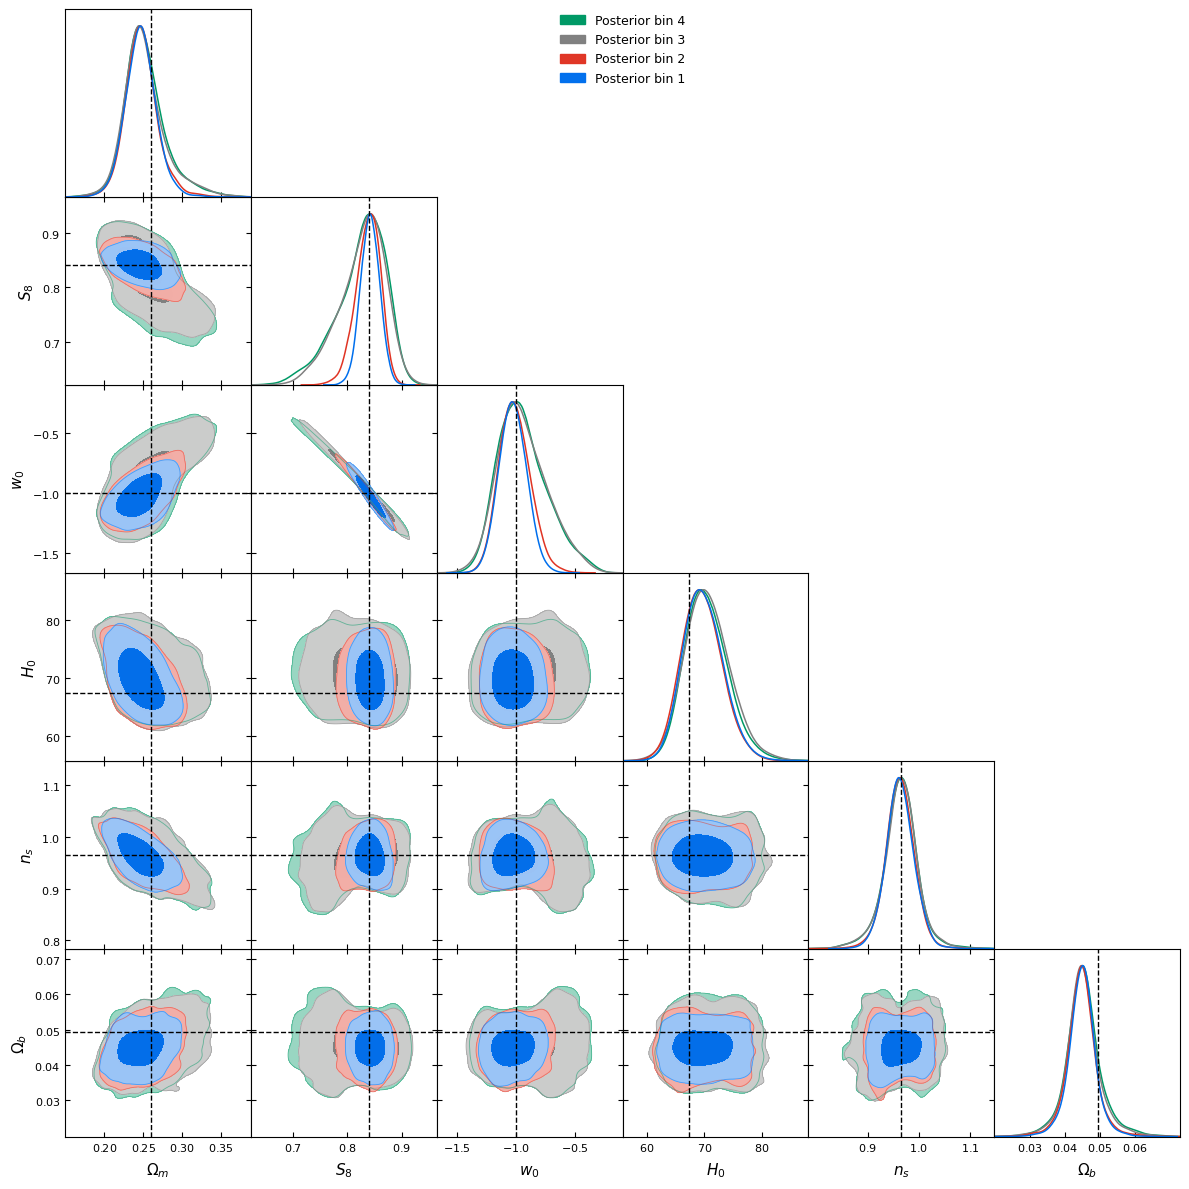

In [115]:
labels = [r"$\Omega_{m}$", r"$S_8$", r"$w_0$", r"$H_0$", r"$n_s$", r"$\Omega_b$"]

g = plots.get_subplot_plotter()

g.settings.figure_legend_frame = False
g.settings.alpha_filled_add = 0.99

g.triangle_plot([samples1_bin4, samples1_bin3, samples1_bin2, samples1_bin1], filled=True,
                markers={
                    label: val for label, val in zip(labels, true_params[0])
                },
                contour_lws=1.1,
                marker_args={'color': 'black',
                             'lw': 1.},
                )
plt.savefig("/home/tersenov/software/bar_impact/plots/posterior_triangle_plot_scale1_bin1vsbin2vsbin3vsbin4_npe.pdf")
plt.show()